# 00 - Raw duty sweep characterization

## Purpose

This notebook is the first in a series working toward an accurate,
mathematically proven servo control loop, built on empirical data. The
series starts from raw ADC readings and derives every quantity in the open.
Later notebooks compare these derivations against what the firmware
computes on the servo.

This notebook has three jobs:

1. Document the measurement chain and the constants that convert ADC
   readings into volts and amperes (section 2).
2. Measure the offset, noise, and limits of each raw channel (section 5).
3. Check that the data follows the expected brushed DC motor behavior
   (section 6).

The dataset is two capture campaigns with identical method, one powered
from a 2-cell lithium battery and one from a 5 V USB source, both on the
same servo and the same board. **The 2S campaign is the primary one and
every number, fit and coefficient below comes from it.** The USB campaign
appears only as a cross-check that a trend points the same way.

The reason is the rail. Across the duty range the USB rail droops a few
percent and it dips much further on spin-up, so a fit against duty on USB
folds rail droop into the duty axis and cannot tell the two apart. The 2S
rail is flat to a few tenths of a percent (section 6.2), so on 2S a fit
against duty is a fit against duty.

An earlier 2S campaign exists in the repository as `_retired-chain2`. It
was taken on the pre-bodge board, whose terminal taps returned to ground,
and no board entry describes it, so the loader refuses to open it. Nothing
below uses it.

## 1. Test setup

The device under test is an SG90-class hobby servo with its stock
electronics replaced by a custom controller board. Both campaigns ran on
that one board and that one servo, so nothing below compares measurement
chains: the only deliberate difference between the two campaigns is the
supply.

- A brushed DC motor driven by an H-bridge with 20 kHz PWM, center
  aligned. The controller commands **duty**. Duty is the fraction of each
  PWM period during which the bridge applies the supply across the motor.
  Duty is signed. Negative duty drives the opposite direction. For the
  rest of the period the bridge shorts the winding through its low-side
  switches (slow decay), the mode used throughout this dataset.
- A gear train couples the motor to the output shaft. A potentiometer on
  the output shaft is read by the MCU's 12-bit ADC. The pot wiper connects
  directly to an ADC pin, so position readings convert to volts at the
  wiper with no divider. Converting wiper volts to output angle needs the
  pot scale, which the servo registry carries as a disputed value (section
  2 prints it with its bracket), so position stays in wiper volts here.
- A shunt resistor in the motor return path, amplified and read by the
  ADC, gives the motor current channel. The recorded value is the
  amplifier output at the ADC pin, offset included.
- Both motor terminals are read through resistor dividers, channels
  `vmotor_a` and `vmotor_b`. The bottom leg of each divider returns to a
  bias node $V_B$ instead of ground, so a terminal that swings below
  ground keeps its ADC pin above ground and stays readable. Each tap has a
  reservoir capacitor, which is what lets the ADC's sample capacitor
  charge quickly from a divider of a few kOhm. Section 2 gives the tap
  formula and the board entry, and section 5.3 measures the bias.
- Each 50 us control period the ADC, clocked at 24 MHz, scans seven
  channels, triggered at the crest of the PWM counter, in the order shunt,
  `vmotor_a`, `vmotor_b`, position, a calibration reference, supply
  sense, and an NTC thermistor. The shunt uses a shorter sample aperture
  than the other channels. A second shunt sample at the trough of the
  counter gives `current_trough`.
- The controller streams every sample at the control rate (20,000 per
  second), packed 16 samples to a frame with a CRC. Corrupted frames are
  dropped and counted, so corruption turns into missing samples (verified
  in section 4). The wire budget at this rate allows six fields per
  sample. These recordings selected the six raw fields (position, both
  shunt samples, applied duty, both terminals). Supply sense and the NTC
  are streamable as `vbus_raw` and `ntc_raw` but were left out, so those
  two columns are empty and play no part in the analysis. The capture
  tool does read the supply-sense channel once per recording, at rest,
  and writes it into the metadata as `vbus_counts`; section 6.2 checks it
  against the rail seen at the motor.

**The board is a hacked rig.** The board under both campaigns is a
development board that has been reworked by hand several times (the shunt,
the dividers, the bias return, the reservoir capacitors, a repaired
amplifier pad). Its entry in the registry says so, and the note prints in
section 2. I know of one defect on it that the next board revision does
not have. The bus telemetry stream couples into the current amplifier's
output, so a shunt sample taken while a frame is going out on the wire can
read a few counts off. On the scan geometry of this firmware build it does
not show at rest (section 5.2 checks this by binning the rest current by
the sample's position inside the 16-sample frame), but it is a known
limitation of this board, and I do not code around it anywhere in this
notebook.

Power for the two campaigns, captured in separate sessions:

- **2S campaign (primary).** A 2-cell lithium battery, nominal 7.4 V,
  measured in section 6.2. This supply is above the 4.8 to 6 V range
  usually quoted for SG90-class servos, so the full-duty steps stress the
  mechanism beyond its usual rating. Its rail is flat across the duty
  range, which is why it is the primary campaign.
- **USB campaign (cross-check).** A laptop USB port. The voltage reaching
  the motor is measured in section 6.2. It is well below the nominal 5 V
  and drops further under load.

## 2. Constants and unit conversions

No constant is written into this notebook. The dataset's `manifest.json`
names a board and a servo; the board is the measurement chain (shunt,
amplifier, dividers, ADC, sample rate, drive-window floors) and the servo
is the mechanism (pot mapping, travel, the measured motor values). Both
live in `oscnb/boards.py` and `oscnb/servos.py`, and the cell below prints
everything they derive, so a reader on GitHub can check the numbers
without running anything.

The shunt, the divider legs, the amplifier gain and VDD are also written
into every recording's `meta.json` by the capture tool (the `sense`
block). Reading a recording checks that block against the board the
manifest names and raises on any disagreement, so a capture taken on
different parts fails at load rather than quietly producing numbers off by
the ratio of two shunts. The bias divider, the reservoir capacitor and the
sampling floors are not in the metadata, so the board entry is the only
record of them.

With the divider's bottom leg returned to the bias $V_B$, a terminal
voltage $V_t$ reaches the ADC pin as

$$\text{tap} = \frac{V_t}{r} + \frac{r - 1}{r} V_B, \qquad V_t = r\,\text{tap} - (r - 1)\, V_B, \qquad r = \frac{R_\text{top} + R_\text{bot}}{R_\text{bot}} .$$

With the bridge off and no current, both taps read $V_B$ exactly, which is
how the bias is measured per recording (section 5.3). Every absolute
terminal voltage below uses the second form with the measured $V_B$ of its
own terminal in its own recording, which is what `board.term_v` does. The
difference of the two terminals is bias-free when both dividers share the
one bias node, so that $v_A - v_B = r\,(\text{tap}_A - \text{tap}_B)$ in
ADC volts, which is `board.diff_v`.

Two caveats:

- The ADC reference is the chip's VDD supply. The figure in the board
  entry is the design value, and the actual VDD of this unit was not
  measured. Every voltage below scales linearly with the true VDD, so one
  future measurement of VDD rescales everything by one factor. Section 10.1
  takes that measurement. Section 10.1
  takes that measurement. Section 10.1
  takes that measurement. Section 10.1
  takes that measurement. Section 10.1
  takes that measurement.
- The divider ratio, shunt and gain are design values. Component
  tolerances were not measured, and absolute voltages and currents carry
  them. The bias itself is measured, so it adds no tolerance of its own.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import oscnb

# The only constant this notebook owns: duty is encoded on the wire as a
# signed q15 fraction. Everything physical comes from the board and servo
# entries the dataset manifests name.
Q15 = 32767

DATASETS = {"2s": "sg90-a__dev-v006-D__2s", "usb": "sg90-a__dev-v006-D__usb"}
DS = {k: oscnb.datasets.load(v) for k, v in DATASETS.items()}

# 2S is primary: its rail is flat, so a fit against duty is a fit against
# duty. Selecting it prints the rig this notebook reports against.
ds = oscnb.use(DATASETS["2s"])
board, servo = oscnb.current().board, oscnb.current().servo

dataset  sg90-a__dev-v006-D__2s
supply   2s
rig      SG90 clone, unit A on osc-dev-v006 board D (bodged toward rev-2A)



,captures,recordings per capture,names
experiment,,,
adccheck,1,1,ladder
breakaway,5,1,sweep
bridge,5,3,"fast, slow, spindown"
grid,10,1,sweep
reversal,5,1,sweep
ripple,5,1,sweep
stall-24mhz,5,1,ladder
stepcoast,5,5,"step120, step20, step40, step60, step80"



derived constants (what the hardware is)


value
where            quantity                                           unit                         
board            converter step                                     mV per count           0.8057
                 terminal divider ratio r                                                  3.0606
                 terminal difference                                mV per count           2.4658
                 terminal bias VB                                   mV                   627.9352
                                                                    counts               779.4008
                 driven-low terminal reads                          counts               524.7451
                 motor current                                      mA per count           0.8952
                                                                    counts per A        1117.0909
                 shunt                                              mOhm                  60.0000
                 amplifier gain                                     x                     15.0000
                 rail tap ratio                                                            2.5000
                 sample rate                                        samples per ms        20.0000
                 current settled from (UNVERIFIED)                  % duty                13.3333
                 voltage settled from (UNVERIFIED)                  % duty                13.3333
servo            pot intercept                                      counts               232.0000
                 pot slope                                          counts per degree     19.9600
                 envelope low                                       counts (10 deg)      431.6000
                 envelope high                                      counts (170 deg)    3625.2000
                 runway                                             counts              3193.6000
                 seek guard low                                     counts               432.0000
                 seek guard high                                    counts              3625.0000
servo (measured) gear_ratio_measured [234.73, 234.73] mechanical... :1                   234.7300
                 ripple_order_measured [6, 6] bringup isns-diff ... per motor rev          6.0000
                 kv_measured [7880, 8040] bringup isns-diff run28   RPM/V               7960.0000
                 kt_measured [1.19, 1.21] bringup isns-diff run28   mN-m/A                 1.2000
                 r_motor_measured [4.16, 4.24] bringup isns-diff... Ohm                    4.2000
                 l_motor_measured [0.45, 0.55] bringup isns-diff... mH                     0.5000
                 stall_current_measured [1.45, 1.55] bringup isn... A                      1.5000
                 stall_torque_measured [1.75, 1.85] bringup isns... mN-m                   1.8000
                 free_run_current_measured [0.078, 0.084] bringu... A                      0.0810
                 r_winding_measured [3.85, 3.99] nb02 part 2, lo... Ohm                    3.9100
                 tau_e_measured [140, 171] nb02 part 2, sample-t... us                   154.0000
                 l_motor_in_servo_measured [0.55, 0.75] nb02 par... mH                     0.6400
                 pot_scale_measured [19.3, 19.43] nb06 sec 5.5, ... counts/deg            19.3000
                 coast_bemf_slope_measured [0.19, 0.204] nb01, c... V per wiper V/s        0.1970
                 ke_measured [7.44, 7.73] nb03 route R: ripple s... mV per motor rev/s     7.5840


measured values (what someone found when they looked)


value                 unit           bracket  \
where quantity                                                            
board vb_bias            781.000               counts        [775, 783]   
      rail_droop_usb      -3.500  % over 20-100% duty          [-4, -3]   
      opa_noise_floor      2.200           counts RMS          [2, 2.4]   
      esd_clamp_skew       1.800               V bemf        [1.7, 1.9]   
servo gear_ratio         234.730                   :1  [234.73, 234.73]   
      ripple_order         6.000        per motor rev            [6, 6]   
      kv                7960.000                RPM/V      [7880, 8040]   
      kt                   1.200               mN-m/A      [1.19, 1.21]   
      r_motor              4.200                  Ohm      [4.16, 4.24]   
      l_motor              0.500                   mH      [0.45, 0.55]   
      stall_current        1.500                    A      [1.45, 1.55]   
      stall_torque         1.800                 mN-m      [1.75, 1.85]   
      free_run_current     0.081                    A    [0.078, 0.084]   
      r_winding            3.910                  Ohm      [3.85, 3.99]   
      tau_e              154.000                   us        [140, 171]   
      l_motor_in_servo     0.640                   mH      [0.55, 0.75]   
      pot_scale           19.300           counts/deg     [19.3, 19.43]   
      coast_bemf_slope     0.197      V per wiper V/s     [0.19, 0.204]   
      ke                   7.584   mV per motor rev/s      [7.44, 7.73]   

                                                                   source  \
where quantity                                                              
board vb_bias                     Hi-Z rest baseline, 2S grid + stepcoast   
      rail_droop_usb                      2S vs USB grid, 5 captures each   
      opa_noise_floor                             bringup isns-diff run29   
      esd_clamp_skew                           bringup isns-diff findings   
servo gear_ratio                          mechanical/sg90/measurements.py   
      ripple_order                           bringup isns-diff runs 25-27   
      kv                                          bringup isns-diff run28   
      kt                                          bringup isns-diff run28   
      r_motor                                     bringup isns-diff run28   
      l_motor                                     bringup isns-diff run28   
      stall_current                               bringup isns-diff run28   
      stall_torque                                bringup isns-diff run28   
      free_run_current                            bringup isns-diff run28   
      r_winding                    nb02 part 2, locked-rotor ladder on 2S   
      tau_e                            nb02 part 2, sample-to-sample pole   
      l_motor_in_servo                           nb02 part 2, tau x R_eff   
      pot_scale         nb06 sec 5.5, travel-weighted ripple cycle cou...   
      coast_bemf_slope                                      nb01, chain 2   
      ke                nb03 route R: ripple speed + coast BEMF over 2...   

                                                                   caveat  
where quantity                                                             
board vb_bias           nominal 779 from the 200/47 network, so 0.3%. ...  
      rail_droop_usb    USB also dips -21.8% transiently at 0.76 A; 2S...  
      opa_noise_floor   arm-B external network at G15; the internal PG...  
      esd_clamp_skew    above this the A-side ESD clamp skews the divi...  
servo gear_ratio        (47*38*32*23)/(10*10*8*7), counted teeth on th...  
      ripple_order      3-segment commutator x 2 brushes; optical tach...  
      kv                bare can, +/-1% HSI scale; pinion stayed on th...  
      kt                                                                   
      r_motor           bare can. nb03 got 4.5 [4.3, 4.8] in-servo via...

## 3. Capture method

The recordings live in the repository under `notebooks/telemetry/`, one
folder per dataset, one subfolder per experiment. This notebook reads the
`grid` experiment of both datasets, whose captures are named
`capture-N`. One capture contains 41 segments, captured back to back:

- **Segment 0** is a one-second baseline with the motor undriven. It
  measures the noise floor of each channel, the current amplifier's
  offset, and the terminal bias.
- **Segments 1 to 40** are constant-duty drive steps, duty from 5% to 100%
  in 5% increments, first forward then reverse. Before each step the servo
  is repositioned at 15% duty toward the far end of travel, so there is
  room to accelerate.

The drive window is **not** a fixed 80 ms any more. Each rung's window is
sized from that supply's own steady-speed fit so that every rung travels
roughly the same distance, about 2554 pot counts, inside the 10 to 170
degree envelope. The schedule prints in each capture's metadata as
`duty@milliseconds`. On 2S the windows run from 1500 ms at 5% duty down to
124 ms at 100%; on USB, where the motor is slower, the same travel needs
1500 ms down to 197 ms. This matters for two reasons: the low rungs get
enough time to show whether they move at all, and the fast rungs stop
before they run out of runway.

Between captures the servo was rebooted and rested, and one warm-up
capture per experiment was discarded, so every capture starts from the
same software state and a similar thermal state. Both campaigns follow this
method exactly. The differences are the supply, the session, and the
window schedule that the supply implies.

**Braking between steps.** After each step's capture window closes, the
sweep tool commands a brief slow-decay brake, which short-circuits the
motor winding and brings the motor to rest. The braking happens after the
capture window, so the recorded data is unaffected.

**Data acceptance.** Any capture in which the host counted even one
dropped frame was discarded and re-run. Section 4 re-verifies this from
the data itself.

Each row of a capture is one 50 us sample, holding the segment number,
commanded duty, direction, tick counter, the firmware's sampling-validity
flag (section 5.4), the raw channels (position, crest and trough shunt
samples, applied duty, both motor terminals), and the empty columns for
supply sense and the NTC. The loader attaches to every capture its
baseline constants, the current offset (mean of `current_raw` over segment
0) and the terminal bias $V_B$ of each terminal (median of `vmotor_a` and
of `vmotor_b` over segment 0).

In [2]:
# Only the streamed columns are kept, as int32: the USB grid alone is ten
# million samples and the full-width float frame does not need to exist.
KEEP = ["seg", "cmd_duty_q15", "dir", "tick", "window_valid", "pos",
        "current_raw", "current_trough", "vmotor_a", "vmotor_b"]

def load_recording(rec):
    # rec.frame() checks the recording's own `sense` block against the board
    # the manifest names and raises on a mismatch. Derived columns: duty_pct
    # (signed percent), t_ms (ms since start), and the per-recording baseline
    # constants bias, vb (terminal A) and vb_b (terminal B).
    df = rec.frame()[KEEP].astype("int32")
    df["duty_pct"] = (df["cmd_duty_q15"] * (100.0 / Q15)).astype("float32")
    df["t_ms"] = ((df["tick"] - df["tick"].iloc[0])
                  / (board.tick_hz / 1000)).astype("float32")
    base = df[df["seg"] == 0]
    df["bias"] = np.float32(base["current_raw"].mean())
    df["vb"] = np.float32(base["vmotor_a"].median())
    df["vb_b"] = np.float32(base["vmotor_b"].median())
    return df, rec.meta

def load_series(key):
    d = DS[key]
    return {cap: load_recording(d.recordings("grid", cap)[0])
            for cap in d.captures("grid")}

# Every loop below walks this list. 2S first, and first is primary.
SERIES = [(k, load_series(k)) for k in ("2s", "usb")]
COLORS = {"2s": "tab:blue", "usb": "tab:orange"}

pd.DataFrame({"captures": [len(recs) for _, recs in SERIES],
              "samples": [sum(len(df) for df, _ in recs.values()) for _, recs in SERIES],
              "role": ["primary", "cross-check"]},
             index=[label for label, _ in SERIES])

,captures,samples,role
2s,10,3368000,primary
usb,20,9672800,cross-check


## 4. Data integrity

The transport turns a corrupted frame into a missing sample. One frame
carries 16 consecutive samples, so a dropped frame appears as a 16-tick
jump in the tick column. The table below recomputes the missing-sample
count for every capture from the tick column.

In [3]:
def integrity(recs):
    rows = []
    for name, (df, meta) in recs.items():
        missing = 0
        for _, seg in df.groupby("seg"):
            ticks = seg["tick"].to_numpy()
            missing += int(ticks[-1] - ticks[0] + 1 - len(ticks))
        rows.append({
            "capture": name,
            "samples": len(df),
            "segments": df["seg"].nunique(),
            "missing_samples": missing,
        })
    return pd.DataFrame(rows)

integ = pd.concat([integrity(recs).assign(series=label) for label, recs in SERIES],
                  ignore_index=True)
integ.groupby("series").agg(captures=("capture", "count"),
                            segments=("segments", "max"),
                            samples_min=("samples", "min"),
                            samples_max=("samples", "max"),
                            missing_samples=("missing_samples", "sum"))

,captures,segments,samples_min,samples_max,missing_samples
series,,,,,
2s,10,41,336800,336800,0
usb,20,41,483640,483640,0


Every capture holds 41 segments with zero missing samples. The sample
counts differ between the two campaigns, and within a campaign they do
not, because the window schedule is per supply and fixed inside a
campaign.

## 5. Channel characterization

### 5.1 Position

The position channel is the pot wiper voltage. The baseline segment of
each capture gives its noise floor at rest. The repositioning move before
the baseline ends with the motor unpowered, and the mechanism can still be
coasting to rest when the capture starts. The code below measures this
residual motion two ways, as the offset of the first 100 ms from the
settled level and as the time of the last sample outside the settled noise
band. The noise statistics drop the first 200 ms of the one-second
baseline and use the settled remainder.

In [4]:
rows = []
for series, recs in SERIES:
    for name, (df, _) in recs.items():
        base = df[df["seg"] == 0]["pos"].to_numpy() * board.v_adc_per_count
        settled = base[len(base) // 5:]
        med = np.median(settled)
        band = np.max(np.abs(settled - med))
        outside = np.where(np.abs(base - med) > band)[0]
        rows.append({
            "series": series,
            "peak_dev_mV": band * 1e3,
            "std_mV": np.std(settled) * 1e3,
            # residual coast from the repositioning move: how far the
            # first 100 ms sits from the settled level, and when the
            # trace last leaves the settled band
            "coast_first_100ms_mV": abs(np.median(base[:2000]) - med) * 1e3,
            "coast_settle_ms": (outside[-1] + 1) / (board.tick_hz / 1000) if len(outside) else 0.0,
        })
pd.DataFrame(rows).groupby("series").agg(["mean", "max"]).round(2)

peak_dev_mV       std_mV       coast_first_100ms_mV        \
              mean   max   mean   max                 mean   max   
series                                                             
2s            3.38  4.03   0.97  1.19                 1.85  2.42   
usb           3.26  4.83   1.01  1.73                 1.09  3.22   

       coast_settle_ms         
                  mean    max  
series                         
2s               46.27   51.5  
usb              45.75  165.6

On the 2S campaign the rest noise has a standard deviation of about 1.0 mV
and a peak deviation under 4.1 mV at the wiper (one ADC count is 0.81 mV,
so the peak deviation is five counts). USB agrees: 1.0 mV standard
deviation and under 4.9 mV peak. The channel does not go through anything
the supply touches, so agreement here is expected and is a check on the
two sessions rather than on the supply.

The mechanism is at rest within about 46 ms on average on both campaigns,
inside the 200 ms trimmed from every baseline, with one USB capture taking
166 ms. Section 6.1 uses the peak deviation as the bound for deciding
whether a drive step produced real motion.

### 5.2 Current offset

The bridge is disabled during the baseline, so no current flows through
the shunt and the baseline reading is the amplifier's output offset. It is
measured below from every baseline segment of both campaigns, with the
rest noise of the channel next to it. The second table is the board caveat
from section 1. It bins the rest current by the sample's position inside
the 16-sample telemetry frame. If the bus stream were reaching the shunt
samples at rest, some positions would read higher than others.

In [5]:
rows = []
for label, recs in SERIES:
    offs = np.array([df["bias"].iloc[0] for df, _ in recs.values()])
    # rest noise: std of the settled baseline (first 200 ms dropped), per capture
    noise = np.array([df[df["seg"] == 0]["current_raw"].to_numpy()[4000:].std()
                      for df, _ in recs.values()])
    off_v = offs.mean() * board.v_adc_per_count
    rows.append({
        "series": label,
        "offset_counts": offs.mean(),
        "offset_counts_min": offs.min(),
        "offset_counts_max": offs.max(),
        "offset_mV": off_v * 1e3,
        "offset_mA_equivalent": off_v / (board.amp_gain * board.shunt_ohm) * 1e3,
        "capture_spread_mV": offs.std() * board.v_adc_per_count * 1e3,
        "rest_noise_std_counts": noise.mean(),
        "rest_noise_std_mA": noise.mean() * board.a_per_count * 1e3,
    })
display(pd.DataFrame(rows).set_index("series").round(2))

# Board caveat check: rest current by position inside the 16-sample frame.
# Position = tick mod 16.
rows = []
for label, recs in SERIES:
    phase = pd.concat([df[df["seg"] == 0].assign(frame_pos=lambda d: d["tick"] % 16)
                       for df, _ in recs.values()])
    by_pos = phase.groupby("frame_pos")[["current_raw", "current_trough"]].mean()
    spread = by_pos.max() - by_pos.min()
    rows.append({"series": label,
                 "samples_per_bin": len(phase) // 16,
                 "crest_spread_counts": spread["current_raw"],
                 "trough_spread_counts": spread["current_trough"],
                 "crest_spread_mA": spread["current_raw"] * board.a_per_count * 1e3})
pd.DataFrame(rows).set_index("series").round(2)

,offset_counts,offset_counts_min,offset_counts_max,offset_mV,offset_mA_equivalent,capture_spread_mV,rest_noise_std_counts,rest_noise_std_mA
series,,,,,,,,
2s,102.669998,100.580002,105.889999,82.720001,91.910004,1.4,1.03,0.92
usb,108.239998,106.629997,110.029999,87.199997,96.889999,0.7,1.32,1.18


,samples_per_bin,crest_spread_counts,trough_spread_counts,crest_spread_mA
series,,,,
2s,12500,0.62,0.82,0.55
usb,25000,0.73,0.85,0.65


Within a campaign the offset is stable to under 1.5 mV across
reboot-separated captures. The 2S session reads 100.6 to 105.9 counts and
the USB session 106.6 to 110.0, so the two sessions differ by about 5.6
counts (4.5 mV) in the mean. The offset is large in both, worth about 92
to 97 mA equivalent through the shunt, so it must be subtracted before
current readings mean anything. Later notebooks subtract the per-capture
baseline value. The rest noise is about 1.0 counts standard deviation on
2S and 1.3 on USB, roughly 1 mA. *Hypothesis (not tested here): the
session difference tracks the board's supply or temperature, since the
amplifier sits on the same 3V3 the ADC references. Testing it requires
baselines on both supplies within one session.*

The frame-position table is flat. Across the sixteen positions the crest
sample spans 0.6 counts on 2S and 0.7 on USB, and the trough sample 0.8
counts on both, against a per-sample noise of 1.0 to 1.3 counts. Each bin
pools at least 12,500 samples, so the spread is real, but it is under
1 mA and well under the noise, which is what I meant by invisible at rest.
It stays on the list as a board limitation.

### 5.3 Terminal bias

With the bridge off and no current in the winding, both terminal dividers
sit at the bias node, so the baseline reads $V_B$ directly on both
channels. The median over the full one-second baseline is robust against
the coasting motor's back-EMF in the first tens of milliseconds. The table
compares the two channels and the nominal value per campaign.

In [6]:
rows = []
for label, recs in SERIES:
    vb = np.array([df["vb"].iloc[0] for df, _ in recs.values()])
    vb_b = np.array([df["vb_b"].iloc[0] for df, _ in recs.values()])
    rows.append({
        "series": label,
        "VB_A_counts_min": vb.min(),
        "VB_A_counts_max": vb.max(),
        "VB_A_mV": vb.mean() * board.v_adc_per_count * 1e3,
        "VB_B_counts_min": vb_b.min(),
        "VB_B_counts_max": vb_b.max(),
        "VB_B_mV": vb_b.mean() * board.v_adc_per_count * 1e3,
        "B_minus_A_counts_min": (vb_b - vb).min(),
        "B_minus_A_counts_max": (vb_b - vb).max(),
        "VB_nominal_counts": board.vb_nom_counts,
        "VB_nominal_mV": board.vb_nom_v * 1e3,
        "VB_A_minus_nominal_mV": (vb.mean() * board.v_adc_per_count - board.vb_nom_v) * 1e3,
        "VB_B_minus_nominal_mV": (vb_b.mean() * board.v_adc_per_count - board.vb_nom_v) * 1e3,
    })
pd.DataFrame(rows).set_index("series").round(2).T

series,2s,usb
VB_A_counts_min,778.000000,778.000000
VB_A_counts_max,778.000000,779.000000
VB_A_mV,626.809998,626.849976
VB_B_counts_min,782.000000,782.000000
VB_B_counts_max,782.000000,782.000000
VB_B_mV,630.030029,630.030029
B_minus_A_counts_min,4.000000,3.000000
B_minus_A_counts_max,4.000000,4.000000
VB_nominal_counts,779.400000,779.400000
VB_nominal_mV,627.940000,627.940000


Both taps sit within a few counts of the 779.4-count nominal in both
campaigns and in every capture: `vmotor_a` reads 778 (0.627 V, 1.1 mV
below nominal) and `vmotor_b` reads 782 (0.630 V, 2.1 mV above), a
four-count split that is the same on 2S and on USB and moves by at most
one count across captures. The registry's measured bias of 781 counts
[775, 783] covers both.

The split is small but it is not zero, and with the bridge off the winding
ties the two terminals together, so both dividers return to the one bias
node and the two taps ought to read the same. Four counts is 3.2 mV at the
pin. Two things could produce it: a real potential difference from bridge
leakage through the dividers, or residual ADC settling, since `vmotor_a`
is scanned right after the shunt channel and `vmotor_b` right after
`vmotor_a`. Section 9 says what would separate them. Either way it is
stable, so every absolute terminal voltage below uses the terminal's own
rest reading as its $V_B$, which absorbs the split as an offset. A
one-count uncertainty in $V_B$ enters an absolute terminal voltage
multiplied by $r - 1$, about 1.6 mV, and is left uncorrected.

### 5.4 Sampling floors and the validity flag

The scan is triggered at the crest of the PWM counter, which under slow
decay is the center of the drive window. The crest sample therefore sits
inside the drive window at every nonzero duty. Whether it is settled
depends on how far the window's edge is from the scan. The board entry
states one floor for current and one for voltage, both printed in section
2 as a duty percentage, and it marks them UNVERIFIED: three different
values for the voltage floor appear in different places in the firmware
tree, and the flashed build was not checked. The firmware stamps every
sample with a validity flag that encodes the current floor. The figure
below shows the driven terminal's raw samples at three duty levels on a 2S
capture, then the table checks where the recorded flag flips.

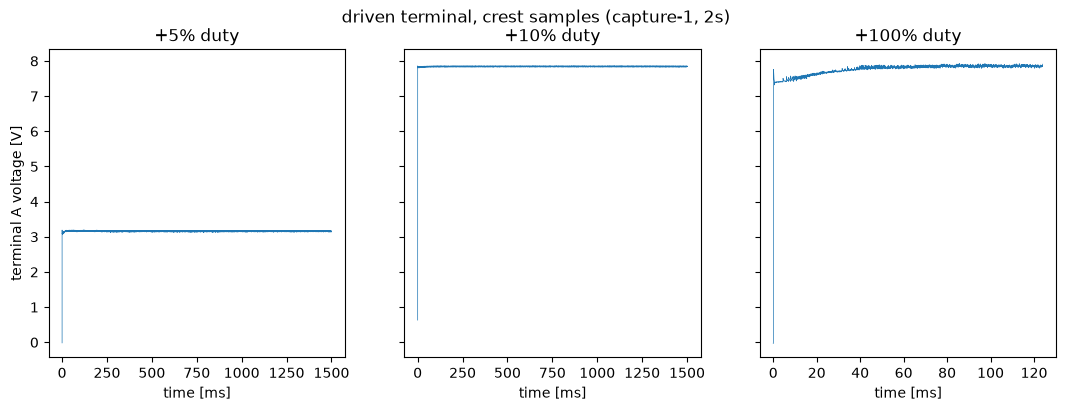

,captures,distinct_flip_points,invalid_up_to_pct,valid_from_pct,configured_current_floor_pct
series,,,,,
2s,10,1,10.0,15.0,13.33
usb,20,1,10.0,15.0,13.33


In [7]:
name, (df, meta) = next(iter(SERIES[0][1].items()))
vb = df["vb"].iloc[0]
fig, axes = plt.subplots(1, 3, figsize=(13, 4), sharey=True)
for ax, pct in zip(axes, [5, 10, 100]):
    seg = df[np.isclose(df["duty_pct"], pct, atol=0.5)]
    t = (seg["tick"] - seg["tick"].iloc[0]) / (board.tick_hz / 1000)
    ax.plot(t, board.term_v(seg["vmotor_a"], vb), lw=0.5)
    ax.set_title(f"+{pct}% duty")
    ax.set_xlabel("time [ms]")
axes[0].set_ylabel("terminal A voltage [V]")
fig.suptitle(f"driven terminal, crest samples ({name}, 2s)")
plt.show()

# Where does the recorded validity flag flip? Checked in every capture of
# both campaigns.
rows = []
for label, recs in SERIES:
    flips = set()
    for df, _ in recs.values():
        v = df[df["seg"] > 0].groupby("seg").agg(
            d=("duty_pct", "first"), valid_frac=("window_valid", "mean"))
        v["mag"] = v["d"].abs().round()
        flips.add((v[v.valid_frac <= 0.5]["mag"].max(),
                   v[v.valid_frac > 0.5]["mag"].min()))
    rows.append({
        "series": label,
        "captures": len(recs),
        "distinct_flip_points": len(flips),
        "invalid_up_to_pct": max(h for h, _ in flips),
        "valid_from_pct": min(l for _, l in flips),
        "configured_current_floor_pct": board.floor_i_pct,
    })
pd.DataFrame(rows).set_index("series").round(2)

At +100% duty the crest sample reads the rail in every period, after a dip
in the first few milliseconds while the rail sags under the inrush and
recovers. At +10% it reads the rail from the first period. At +5% it reads
about 3.1 V against a 7.65 V rail, less than half, because the drive
window's edge is 60 ticks from the scan and the divider has not settled.
The motor still receives its share of the supply during that step, and the
position data in section 6.1 shows what it does with it.

The recorded flag flips between the 10% and 15% duty steps in every
capture of both campaigns, which is the single flip point the 13.3%
current floor implies on this 5% grid.

The two terminals settle at different duty. The table below pools the
driven terminal's median reading per step across all captures, terminal A
for forward steps and terminal B for reverse, each bias-corrected with its
own rest reading.

In [8]:
rows = []
for label, recs in SERIES:
    for df, _ in recs.values():
        vb_a, vb_b = df["vb"].iloc[0], df["vb_b"].iloc[0]
        for seg_id, seg in df.groupby("seg"):
            d = seg["duty_pct"].iloc[0]
            mag = int(round(abs(d)))
            if seg_id == 0 or mag > 25:
                continue
            term, vbx = (seg["vmotor_a"], vb_a) if d > 0 else (seg["vmotor_b"], vb_b)
            rows.append({
                "series": label,
                "terminal": "A (forward)" if d > 0 else "B (reverse)",
                "duty_mag_pct": mag,
                "driven_V": board.term_v(term.median(), vbx),
            })
(pd.DataFrame(rows)
   .groupby(["duty_mag_pct", "series", "terminal"])["driven_V"].mean()
   .unstack(["series", "terminal"]).round(2))

series                2s                     usb            
terminal     A (forward) B (reverse) A (forward) B (reverse)
duty_mag_pct                                                
5                   3.14        0.13        1.72        0.07
10                  7.79        5.20        4.66        2.97
15                  7.79        7.73        4.65        4.62
20                  7.79        7.73        4.64        4.61
25                  7.79        7.73        4.63        4.60

This settles the voltage floor from data. On 2S terminal A reads the full
7.79 V rail from the 10% step, but terminal B reads 5.20 V there against
7.73 V from 15% up, so terminal B's window edge lies between 10% and 15%
duty. USB shows the same shape: A settled from 10% at 4.66 V, B at 2.97 V
at 10% and 4.62 V from 15%. The configured floor of 13.3% (160 timer
ticks) is the only one of the three candidates that covers both terminals:
a 120-tick floor would pass terminal B samples at the 10% step that are
30% low. The floor stays marked unverified in the registry because that is
a statement about the flashed firmware, not about this data, but this data
is consistent with 160 ticks and rules out 120.

This imposes two rules on everything below:

- Current readings and terminal voltage readings are used only where the
  validity flag is set, which on this grid means the 15% step and up, and
  additionally at or above the configured voltage floor.
- Below those floors the position channel is the only trusted channel.
  The pot wiper is sampled directly, outside the PWM window, so position
  has no such limit.

## 6. Results

### 6.1 Motion threshold

For each drive step, net travel is the difference between the median of
the last 20 and the first 20 position samples (medians so a single noise
spike cannot fake motion). This is compared against the rest-noise band
from section 5.1. One complication needs handling. Each drive step begins
shortly after a repositioning move, and the mechanism can still be
coasting from that move when the step begins (section 5.1 measures this in
the baselines). Drive-produced motion follows the commanded direction.
Residual coast follows the repositioning move, which by construction of
the test runs opposite the drive direction. So besides the per-step
scatter, the table pools travel aligned with the drive direction across
all captures.

Because the windows are sized for equal travel, the plateau at the right
of each panel is the design of the schedule and not a fact about the
motor. The left end, where the schedule gives the low rungs 1500 ms, is
the part that carries information.

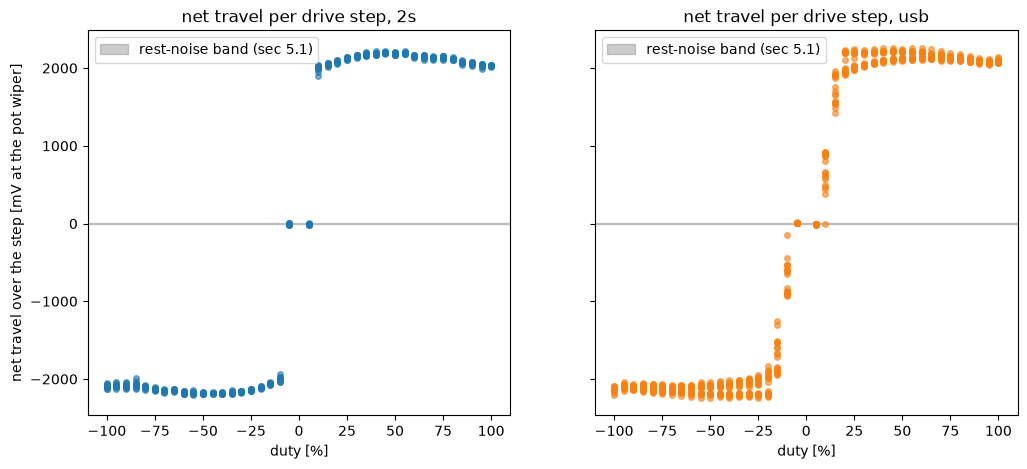

2s                         usb                     
                mean   std     min count    mean    std     min count
duty_mag_pct                                                         
5.0             -1.0  11.2   -18.5    20    -7.9    3.7   -17.7    40
10.0          1994.1  36.7  1894.9    20   699.1  228.4     0.0    40
15.0          2053.0  16.2  2015.0    20  1725.9  194.9  1259.7    40
20.0          2096.0  18.4  2056.9    20  2072.8  132.1  1832.1    40

,rest-noise band [mV]
2s,4.03
usb,4.83


In [9]:
def step_travel(df):
    out = []
    for seg_id, seg in df.groupby("seg"):
        if seg_id == 0:
            continue
        p = seg["pos"].to_numpy() * board.v_adc_per_count * 1e3   # mV at the wiper
        out.append({
            "duty_pct": seg["duty_pct"].iloc[0],
            "travel_mV": np.median(p[-20:]) - np.median(p[:20]),
        })
    return pd.DataFrame(out)

def rest_band_mV(df):
    base = df[df["seg"] == 0]["pos"].to_numpy() * board.v_adc_per_count * 1e3
    settled = base[len(base) // 5:]
    return np.max(np.abs(settled - np.median(settled)))

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
bands = {}
for ax, (title, recs) in zip(axes, SERIES):
    band = 0.0
    for name, (df, meta) in recs.items():
        tr = step_travel(df)
        band = max(band, rest_band_mV(df))
        ax.plot(tr["duty_pct"], tr["travel_mV"], "o", ms=4, alpha=0.6,
                color=COLORS[title])
    bands[title] = band
    ax.axhspan(-band, band, color="grey", alpha=0.4,
               label="rest-noise band (sec 5.1)")
    ax.set_xlabel("duty [%]")
    ax.set_title(f"net travel per drive step, {title}")
    ax.legend(loc="upper left")
axes[0].set_ylabel("net travel over the step [mV at the pot wiper]")
plt.show()

# Drive-aligned travel by |duty| in mV; positive = moved in the
# commanded direction.
tables = {}
for label, recs in SERIES:
    allt = pd.concat([step_travel(df) for df, _ in recs.values()])
    allt["aligned_mV"] = allt["travel_mV"] * np.sign(allt["duty_pct"])
    tables[label] = (allt.assign(duty_mag_pct=np.abs(allt["duty_pct"]).round())
                         .groupby("duty_mag_pct")["aligned_mV"]
                         .agg(["mean", "std", "min", "count"]).head(4))
aligned = pd.concat(tables, axis=1)
display(aligned.round(1))
pd.Series(bands, name="rest-noise band [mV]").round(2).to_frame()

Findings:

- At 10% duty the servo moves. On 2S the mean aligned travel is 1994 mV
  over the 1500 ms window and the smallest of the twenty steps is 1895 mV,
  clearing the 4.0 mV rest-noise band by nearly three orders of magnitude.
  USB agrees in direction and disagrees in margin: its mean is 699 mV with
  a standard deviation of 228 mV and a minimum of exactly zero, so some
  10% steps on USB do not break away at all. That is the same threshold
  seen from the other side, and section 9 keeps it.
- At 5% duty the aligned travel is within a few millivolts of zero on 2S
  (mean -1.0 mV against a 4.0 mV band) and slightly negative on USB (mean
  -7.9 mV, spread 3.7). Drive cannot produce motion opposite the command.
  Residual coast can, and its direction opposes the drive direction here by
  construction. The 5% steps are therefore consistent with zero
  drive-produced motion on both supplies.

So the motion threshold of this unit lies between 5% and 10% duty on both
supplies. Section 6.2 converts this duty bracket into a voltage bracket
once the rail is measured.

### 6.2 Supply voltage under load

These recordings carry no per-sample supply-sense channel (section 1).
They have the two motor terminals. While the bridge drives, the driven
terminal connects to the supply through the high-side switch, so its
voltage is the supply minus the switch drop. The estimate below takes, per
drive step, the 90th percentile of the driven terminal's valid samples
(terminal A when driving forward, terminal B in reverse), bias-corrected
with that terminal's own $V_B$ from the capture and restricted to duty at
or above the configured voltage floor. Steps below the floor have no valid
voltage samples and are absent from the figure. The table also reports the
partner terminal at full duty, which the low-side switch holds near
ground, as a check on the bias correction, and the once-per-capture
supply-sense reading from the metadata converted through the board's rail
tap.

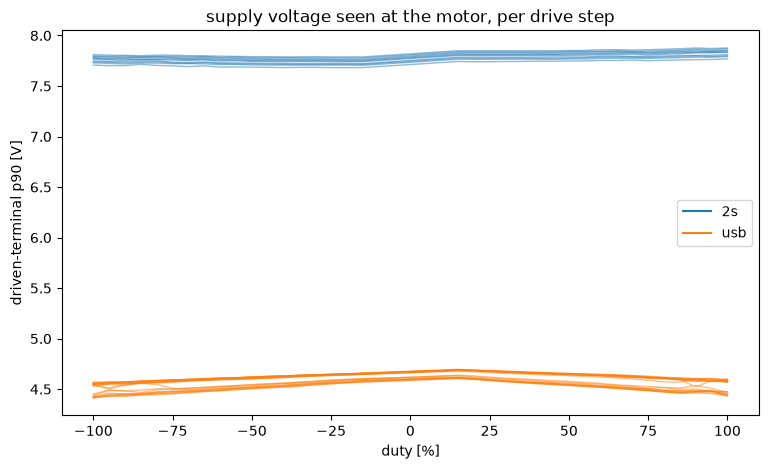

,light_load_V,full_duty_V,droop_20_to_100_pct,low_side_full_duty_V,vsense_rest_V,vsense_over_terminal
series,,,,,,
2s,7.771,7.793,0.290,0.131,6.383,0.821
usb,4.629,4.519,-2.452,0.070,3.811,0.823


registry rail droop on USB: -3.5 % over 20-100% duty [-4, -3] (2S vs USB grid, 5 captures each) - USB also dips -21.8% transiently at 0.76 A; 2S is flat (+0.1%) and dips only -5.9% at 1.70 A. ~1.3 ohm vs ~0.27 ohm source Z


In [10]:
def step_supply(df):
    # Supply estimate per drive step: p90 of the driven terminal, valid
    # samples at or above the voltage floor only. low_side_V is the
    # median of the partner terminal over the same samples. Each terminal
    # is bias-corrected with its own rest reading.
    vb_a, vb_b = df["vb"].iloc[0], df["vb_b"].iloc[0]
    out = []
    for seg_id, seg in df.groupby("seg"):
        if seg_id == 0:
            continue
        d = seg["duty_pct"].iloc[0]
        if abs(d) < board.floor_v_pct:
            continue
        v = seg[seg["window_valid"] == 1]
        if len(v) < 100:
            continue
        if d > 0:
            hi, lo, vbh, vbl = v["vmotor_a"], v["vmotor_b"], vb_a, vb_b
        else:
            hi, lo, vbh, vbl = v["vmotor_b"], v["vmotor_a"], vb_b, vb_a
        out.append({"duty_pct": d,
                    "supply_V": board.term_v(hi.quantile(0.9), vbh),
                    "low_side_V": board.term_v(lo.median(), vbl)})
    return pd.DataFrame(out).sort_values("duty_pct")

SUPPLY = {label: {name: step_supply(df) for name, (df, _) in recs.items()}
          for label, recs in SERIES}

fig, ax = plt.subplots(figsize=(9, 5))
for label, recs in SERIES:
    for name in recs:
        r = SUPPLY[label][name]
        ax.plot(r["duty_pct"], r["supply_V"], "-", lw=1, alpha=0.5, color=COLORS[label])
    ax.plot([], [], "-", color=COLORS[label], label=label)
ax.set_xlabel("duty [%]")
ax.set_ylabel("driven-terminal p90 [V]")
ax.set_title("supply voltage seen at the motor, per drive step")
ax.legend()
plt.show()

rows = []
for label, recs in SERIES:
    hi, lo, ls, d20 = [], [], [], []
    for name, (df, meta) in recs.items():
        r = SUPPLY[label][name]
        mag = r["duty_pct"].abs().round()
        full = r[mag >= 95]
        lo.append(full["supply_V"].mean())
        ls.append(full["low_side_V"].mean())
        hi.append(r[mag <= 30]["supply_V"].mean())
        d20.append(r[mag == 20]["supply_V"].mean())
    meta = next(iter(recs.values()))[1]
    rows.append({
        "series": label,
        "light_load_V": np.mean(hi),
        "full_duty_V": np.mean(lo),
        "droop_20_to_100_pct": (np.mean(lo) / np.mean(d20) - 1) * 100,
        "low_side_full_duty_V": np.mean(ls),
        "vsense_rest_V": board.vsys_v(meta["vbus_counts"]),
        "vsense_over_terminal": board.vsys_v(meta["vbus_counts"]) / np.mean(hi),
    })
supply = pd.DataFrame(rows).set_index("series")
display(supply.round(3))
print("registry rail droop on USB:", board.measured["rail_droop_usb_measured"])

Findings:

- **The 2S rail is flat.** It delivers 7.77 V at light load and 7.79 V at
  full duty, and from the 20% rung to the 100% rung it changes by +0.3%. That is
  why every fit in this notebook is on 2S: on this rail, duty times supply
  and duty differ by a constant.
- **The USB rail is not.** It delivers 4.63 V at light load, already well
  below the nominal 5 V, and 4.52 V at full duty, a droop of -2.5% over
  the same range. The registry carries this as
  `rail_droop_usb_measured` = -3.5% [-4.0, -3.0] from the same campaign;
  the driven-terminal p90 used here reads -2.5%, half a point outside
  that bracket, and section 9 keeps the gap. Either way the sign and
  the order of magnitude are the same, and the first few milliseconds of
  every high-duty step dip much lower than the p90 shows (the +100% panel
  of section 5.4). *Hypothesis (not tested here): the standing deficit and
  the load dependence are resistive and diode drops in the cable,
  connectors, and the board's input path. Testing it requires measuring
  the voltage at the port and at the board input at the same time.*
- The low-side terminal reads 0.131 V (2S) and 0.070 V (USB) at full duty
  after the bias correction, the drop across the conducting low-side
  switch and the shunt. Without the correction it would read
  $(r - 1) V_B$ higher, about 1.29 V.
- **The once-per-capture supply-sense reading does not agree with the
  motor rail.** Through the board's declared rail tap it comes out at
  6.38 V on 2S and 3.81 V on USB, 18% below the terminal p90 on both. It
  cannot be right: the driven terminal is fed from that same rail through
  the high-side switch, so it can only read *below* the rail, never above.
  Section 9 has the candidate causes and the measurement that separates
  them. Nothing below uses `vbus_counts`.

Every fit below that divides by supply voltage therefore uses the
per-step measured value from the terminal.

**The motion threshold as a voltage.** If the threshold of section 6.1 is
a fixed voltage (the voltage needed to overcome friction), the relevant
axis is duty times the supply voltage. The table applies the light-load
rail of each campaign to its 5% and 10% steps and marks which of them
moved (aligned travel beyond the rest-noise band).

In [11]:
rows = []
for label, _ in SERIES:
    for pct in [5, 10]:
        rows.append({
            "series": label,
            "duty_pct": pct,
            "applied_V": pct / 100.0 * supply.loc[label, "light_load_V"],
            "aligned_travel_mV": aligned.loc[pct, (label, "mean")],
            "worst_step_mV": aligned.loc[pct, (label, "min")],
            "moved": bool(aligned.loc[pct, (label, "mean")] > bands[label]),
        })
pd.DataFrame(rows).set_index(["series", "duty_pct"]).round(2)

applied_V  aligned_travel_mV  worst_step_mV  moved
series duty_pct                                                    
2s     5              0.39              -1.01         -18.53  False
       10             0.78            1994.10        1894.92   True
usb    5              0.23              -7.93         -17.72  False
       10             0.46             699.06           0.00   True

On the primary campaign the highest step that did not move is the 2S 5%
step at 0.39 V and the lowest step that moved is the 2S 10% step at
0.78 V, so 2S alone brackets the threshold a factor of two wide. The USB
cross-check squeezes it from the other side: its 10% step at 0.46 V moved
in the mean but its worst step did not move at all, which places the
threshold right at 0.46 V rather than merely below it. Combining the two,
the minimum voltage that produces motion is close to 0.46 V and lies
between 0.39 and 0.46 V for this unit. This is the one place where the USB
campaign adds more than confirmation, and it does so because the threshold
is a voltage that USB happens to sit on, not because anything is fitted to
USB. Why a DC motor needs a minimum voltage to start moving is a friction
question, taken up in notebook 04, and the `breakaway` experiment in both
datasets attacks it directly.

### 6.3 Speed vs effective voltage

For each drive step above the motion threshold, the steady speed is the
slope of a least-squares line through the last 60% of the step's position
trace, past the initial acceleration. For a brushed DC motor at steady
speed, the average applied voltage is duty times the supply voltage, and
speed rises linearly with it. **The fitted line is the 2S one.** The USB
line is fitted the same way and shown next to it, but only to answer one
question: does the same relationship hold at a rail 3 V lower? It is not
the source of any coefficient, because on a drooping rail the duty axis
and the rail axis are not independent.

Steps below the voltage floor have no same-step supply measurement. Those
steps use the mean supply of the gentlest measurable steps of the same
capture (up to 30% duty). The fit table also repeats the fit with one
supply value per campaign (the mean over all measurable steps) to show
what the per-step correction is worth.

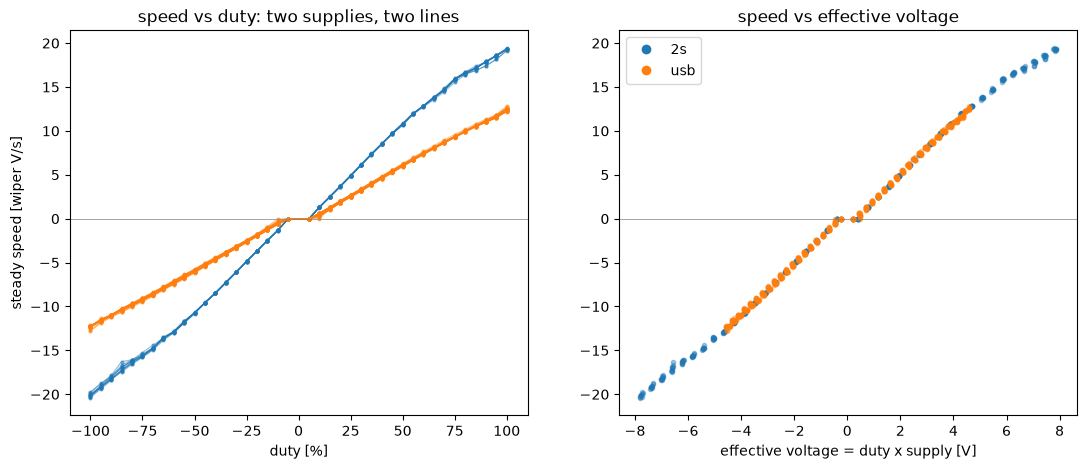

,2s slope_Vps_per_V,2s intercept_Vps,usb slope_Vps_per_V,usb intercept_Vps,usb_minus_2s_pct
per-step supply,2.626,-0.062,2.685,0.030,2.255
single supply per series,2.628,-0.017,2.668,0.053,1.528


In [12]:
def step_speeds(df, sup_tab):
    sup = sup_tab.set_index("duty_pct")["supply_V"]
    sup_lo = sup[np.abs(sup.index) <= 30].mean()
    out = []
    for seg_id, seg in df.groupby("seg"):
        if seg_id == 0:
            continue
        n = len(seg)
        tail = seg.iloc[int(n * 0.4):]
        t = (tail["tick"] - tail["tick"].iloc[0]) / board.tick_hz
        slope = np.polyfit(t, tail["pos"] * board.v_adc_per_count, 1)[0]
        d = seg["duty_pct"].iloc[0]
        out.append({
            "duty_pct": d,
            "speed_Vps": slope,                       # wiper volts per second
            "supply_V": sup.get(d, sup_lo),
            "supply_mean_V": sup.mean(),
        })
    return pd.DataFrame(out)

SPEEDS = {label: {name: step_speeds(df, SUPPLY[label][name])
                  for name, (df, _) in recs.items()}
          for label, recs in SERIES}

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for label, recs in SERIES:
    for name in recs:
        sp = SPEEDS[label][name].sort_values("duty_pct")
        axes[0].plot(sp["duty_pct"], sp["speed_Vps"], "-o", ms=2, lw=0.8,
                     alpha=0.5, color=COLORS[label])
        veff = sp["duty_pct"] / 100.0 * sp["supply_V"]
        axes[1].plot(veff, sp["speed_Vps"], "o", ms=3, alpha=0.4, color=COLORS[label])
    axes[1].plot([], [], "o", color=COLORS[label], label=label)
axes[0].set_xlabel("duty [%]")
axes[0].set_ylabel("steady speed [wiper V/s]")
axes[0].set_title("speed vs duty: two supplies, two lines")
axes[1].set_xlabel("effective voltage = duty x supply [V]")
axes[1].set_title("speed vs effective voltage")
axes[1].legend()
for ax in axes:
    ax.axhline(0, color="grey", lw=0.5)
plt.show()

fits = {}
for label, recs in SERIES:
    pts = pd.concat(SPEEDS[label].values())
    for kind, col in [("per-step supply", "supply_V"),
                      ("single supply per series", "supply_mean_V")]:
        veff = pts["duty_pct"] / 100.0 * pts[col]
        m = veff.abs() > 1.0     # fit above 1 V, clear of the motion threshold
        k = np.polyfit(veff[m], pts["speed_Vps"][m], 1)
        fits.setdefault(kind, {})[f"{label} slope_Vps_per_V"] = k[0]
        fits[kind][f"{label} intercept_Vps"] = k[1]
fits = pd.DataFrame(fits).T
fits["usb_minus_2s_pct"] = (
    (fits["usb slope_Vps_per_V"] - fits["2s slope_Vps_per_V"])
    / fits["2s slope_Vps_per_V"] * 100)
fits.round(3)

Findings:

- **The number.** On the 2S campaign the steady speed rises at 2.626 wiper
  V/s per volt of effective voltage, with an intercept of -0.06 wiper V/s.
  That is the speed-voltage constant this notebook hands on. It is fitted
  on a rail that moves by 0.3% across the whole duty range, so nothing in
  it is rail droop wearing a duty costume.
- Against duty (left panel), the two campaigns separate. The 2S line is
  straight and steeper by roughly the ratio of the supply voltages, and the
  USB curve bends as its rail sags, so duty alone does not predict speed.
- Against effective voltage (right panel), the two campaigns come close to
  one line. The USB slope is 2.685, 2.2% above the 2S one. The linear
  speed-voltage relationship of the brushed DC motor model therefore holds
  across a 4.6 V and a 7.8 V rail to about two percent, with no calibration
  involved. That is the cross-check, and it passes.
- The per-step supply correction is no longer worth anything, and this is
  a change from the earlier version of this notebook. With one supply value
  per campaign the two slopes differ by 1.5%; with the per-step value they
  differ by 2.2%. The per-step correction moves the 2S slope by 0.1% and
  the USB slope by 0.6%, and it moves USB the wrong way. *Hypothesis (not
  tested here): the p90 of the driven terminal overstates the average
  voltage the USB supply delivered within a step, since the USB rail swings
  far more within a step than the 2S pack does, and the p90 is by
  construction near the top of that swing. Testing it needs a per-sample
  effective voltage in place of the per-step p90, which needs the
  bridge-state gating of notebook 01.*

### 6.4 Repeatability across captures

Each campaign is a run of identical captures separated by reboots and
cooldowns, so drift across captures reflects the hardware. The figure
shows the steady speed of the +100% duty step for every capture, in order.

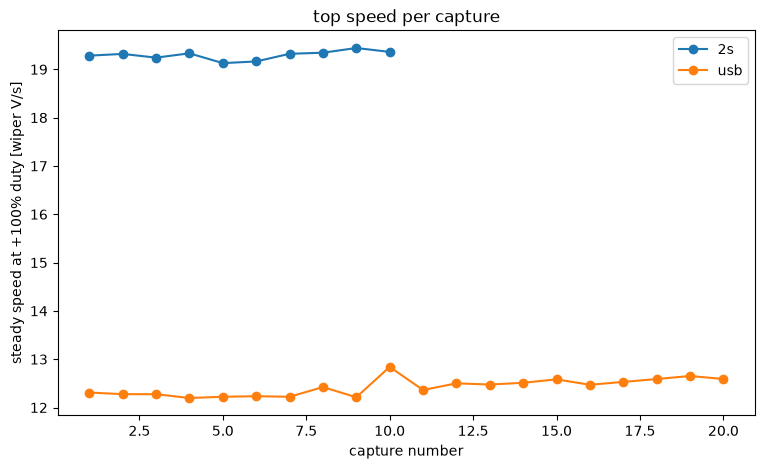

,captures,mean_Vps,first_Vps,last_Vps,spread_pct
series,,,,,
2s,10,19.293,19.283,19.361,1.623
usb,20,12.424,12.310,12.590,5.183


In [13]:
fig, ax = plt.subplots(figsize=(9, 5))
rows = []
for label, recs in SERIES:
    xs, ys = [], []
    for name in recs:
        n = int(name.split("-")[1])
        sp = SPEEDS[label][name]
        row = sp[np.isclose(sp["duty_pct"], 100.0, atol=0.1)]
        xs.append(n)
        ys.append(row["speed_Vps"].iloc[0])
    order = np.argsort(xs)
    xs, ys = np.array(xs)[order], np.array(ys)[order]
    ax.plot(xs, ys, "-o", color=COLORS[label], label=label)
    rows.append({"series": label,
                 "captures": len(ys),
                 "mean_Vps": np.mean(ys),
                 "first_Vps": ys[0],
                 "last_Vps": ys[-1],
                 "spread_pct": (max(ys) - min(ys)) / np.mean(ys) * 100})
ax.set_xlabel("capture number")
ax.set_ylabel("steady speed at +100% duty [wiper V/s]")
ax.set_title("top speed per capture")
ax.legend()
plt.show()
pd.DataFrame(rows).set_index("series").round(3)

The 2S captures agree within 1.6% at full duty across ten captures, with
no trend: 19.28 wiper V/s in the first and 19.36 in the last, against a
mean of 19.29. The USB captures scatter 5.2% across twenty, three times
wider, and the full-duty rail moved by only a few millivolts over the same
run, so the rail level does not explain it. Plausible contributors include
thermal state of the gear train and the motor, and the fact that a USB
full-duty step sits much closer to the motion threshold in torque terms.
Neither is isolated here. Any single capture carries a few percent of
unexplained variation, so fits in later notebooks pool across captures,
and the 2S campaign is the one to pool.

## 7. Limitations and open issues

- **One unit.** All numbers describe this one servo and this one board.
  The gear train has prior wear.
- **The board is a hacked rig.** Section 1 describes it, and its registry
  entry says so in the table of section 2. The bus telemetry stream
  couples into the current amplifier output on this board. It is flat
  within about a count at rest on this firmware build (section 5.2), but
  it is a limitation of the board, and I leave it as one. The next board
  revision does not have it, and nothing in this notebook is written to
  dodge it.
- **Voltages are nominal-referenced.** All voltages scale with the true
  VDD of this unit, which was not measured (section 2). The terminal bias
  is measured per capture and per terminal, but the divider ratio it
  enters with is a design value. **Superseded by section 10.1**, where a
  meter puts VDD at 3.28 V against the declared 3.30, so every absolute
  volt and amp in sections 1 to 9 reads 0.61% high. Section 10 applies the
  correction wherever it quotes an absolute number. **Superseded by section 10.1**, where a
  meter puts VDD at 3.28 V against the declared 3.30, so every absolute
  volt and amp in sections 1 to 9 reads 0.61% high. Section 10 applies the
  correction wherever it quotes an absolute number. **Superseded by section 10.1**, where a
  meter puts VDD at 3.28 V against the declared 3.30, so every absolute
  volt and amp in sections 1 to 9 reads 0.61% high. Section 10 applies the
  correction wherever it quotes an absolute number. **Superseded by section 10.1**, where a
  meter puts VDD at 3.28 V against the declared 3.30, so every absolute
  volt and amp in sections 1 to 9 reads 0.61% high. Section 10 applies the
  correction wherever it quotes an absolute number. **Superseded by section 10.1**, where a
  meter puts VDD at 3.28 V against the declared 3.30, so every absolute
  volt and amp in sections 1 to 9 reads 0.61% high. Section 10 applies the
  correction wherever it quotes an absolute number.
- **Angles are not.** The servo entry's pot scale is disputed by 9%
  between an eyeballed three-point fit and the ripple tach (both print in
  section 2 with their brackets), so this notebook reports position in
  wiper volts and never in degrees.
- **Position linearity is not established.** The pot's voltage-vs-angle
  linearity is not measured here. Nothing in this notebook depends on it.
  Fits that combine distant regions of travel will have to address it.
- **The windows are sized, not fixed.** Every rung travels about the same
  distance, so the net-travel panel of section 6.1 is flat by
  construction above the threshold and says nothing about speed there.
  Speed comes from the slope inside the window (section 6.3), not from
  the travel.
- **The sampling floors are this board's**, and the registry still marks
  them unverified against the flashed firmware. Section 5.4 shows the data
  is consistent with the 160-tick voltage floor and rules out 120, which
  is not the same as reading the build.
- **Supply sense and NTC are not streamed.** The six-field wire budget
  left `vbus_raw` and `ntc_raw` out, so the rail is inferred from the
  driven terminal (section 6.2) and temperature is unobserved. The
  once-per-capture `vbus_counts` in the metadata does not currently agree
  with the terminal (section 9).
- **The two campaigns are different sessions.** The current offset differs
  between them by 5.6 counts (section 5.2), so nothing here pools baseline
  constants across supplies.
- **2S exceeds the servo's usual rating.** The full-duty 2S steps apply
  about 7.8 V to a mechanism usually rated 4.8 to 6 V.

## 8. Next notebooks

The same measurement chain supports the next derivations, each one
checked against the firmware's on-servo computation:

- Notebook 01 establishes what each of the four bridge states does to the
  terminals, the shunt and the motion, and gates every later sample on
  the bridge state.
- Notebook 03 derives the back-EMF constant, notebook 04 the friction,
  including the motion threshold measured here, and notebook 05 the
  inertia.
- The firmware's supply estimator and current-offset handling, re-derived
  from this raw data and compared against the servo's live values.

## 9. Open discrepancies

Each entry is something this notebook measured that does not add up, the
candidate causes, and the one experiment that would tell those causes
apart. Nothing here is resolved by more analysis of these captures.

**9.1 The supply-sense channel reads 18% below the motor rail.**
Through `board.vsys_v` the metadata's rest reading is 6.38 V on 2S and
3.81 V on USB, against 7.77 V and 4.63 V at the driven terminal (section
6.2). The sign is impossible: the terminal is fed from the rail through
the high-side switch. Candidates: (a) the rail tap on this bodged board is
not the 15k/10k the board entry declares - multiplying the same counts by
the *terminal* divider ratio instead reproduces both terminal readings to
better than half a percent, which is what a bodge that reused the terminal
divider parts would look like; (b) the capture tool writes a pre-scaled
value into `vbus_counts` rather than raw counts; (c) a real drop between
the sensed node and the bridge, which (a) and the sign both argue against.
**Experiment that separates them:** with the board unpowered, measure the
two VSNS divider legs with an ohmmeter; then feed VSYS from a bench supply
at two known voltages and log `vbus_counts` at each. Case (a) shows the
declared legs to be wrong and a straight line through the origin with the
terminal ratio; case (b) shows the correct legs and a scale factor in the
tool; case (c) shows the correct legs and a load-dependent offset.

*Narrowed by the instrument session, and candidate (a) is out (section 10.2).*
The grid captures stream the raw rail tap `vbus_raw`, which these sweep
captures did not. Through the declared 15k/10k legs it gives 7.13 V at rest on
2S and 4.90 V on USB, and under 1.69 A it gives 6.78 V against 6.67 V at the
driven terminal, so the rail sits ABOVE the terminal by the 0.11 V high-side
switch drop, which is the right sign. On the same recording the metadata's
`vbus_counts` lands on that rail to better than 0.1% when it goes through the
*terminal* ratio, and 18.3% below it through the rail divider, which is the 18%
in the paragraph above. So the legs are fine and the field was never raw counts. The
firmware's supply estimator rescales `vbus_counts` into terminal-tap units
before it reaches the metadata, which is case (b) in substance rather than in
the form it was guessed at. Still owed: the ohmmeter on the two legs with the
board unpowered. Until that is done this is refutation by agreement between two
routes, not by measurement.

*Narrowed by the instrument session, and candidate (a) is out (section 10.2).*
The grid captures stream the raw rail tap `vbus_raw`, which these sweep
captures did not. Through the declared 15k/10k legs it gives 7.13 V at rest on
2S and 4.90 V on USB, and under 1.69 A it gives 6.78 V against 6.67 V at the
driven terminal, so the rail sits ABOVE the terminal by the 0.11 V high-side
switch drop, which is the right sign. On the same recording the metadata's
`vbus_counts` lands on that rail to better than 0.1% when it goes through the
*terminal* ratio, and 18.3% below it through the rail divider, which is the 18%
in the paragraph above. So the legs are fine and the field was never raw counts. The
firmware's supply estimator rescales `vbus_counts` into terminal-tap units
before it reaches the metadata, which is case (b) in substance rather than in
the form it was guessed at. Still owed: the ohmmeter on the two legs with the
board unpowered. Until that is done this is refutation by agreement between two
routes, not by measurement.

*Narrowed by the instrument session, and candidate (a) is out (section 10.2).*
The grid captures stream the raw rail tap `vbus_raw`, which these sweep
captures did not. Through the declared 15k/10k legs it gives 7.13 V at rest on
2S and 4.90 V on USB, and under 1.69 A it gives 6.78 V against 6.67 V at the
driven terminal, so the rail sits ABOVE the terminal by the 0.11 V high-side
switch drop, which is the right sign. On the same recording the metadata's
`vbus_counts` lands on that rail to better than 0.1% when it goes through the
*terminal* ratio, and 18.3% below it through the rail divider, which is the 18%
in the paragraph above. So the legs are fine and the field was never raw counts. The
firmware's supply estimator rescales `vbus_counts` into terminal-tap units
before it reaches the metadata, which is case (b) in substance rather than in
the form it was guessed at. Still owed: the ohmmeter on the two legs with the
board unpowered. Until that is done this is refutation by agreement between two
routes, not by measurement.

*Narrowed by the instrument session, and candidate (a) is out (section 10.2).*
The grid captures stream the raw rail tap `vbus_raw`, which these sweep
captures did not. Through the declared 15k/10k legs it gives 7.13 V at rest on
2S and 4.90 V on USB, and under 1.69 A it gives 6.78 V against 6.66 V at the
driven terminal, so the rail sits ABOVE the terminal by the 0.11 V high-side
switch drop, which is the right sign. On the same recording the metadata's
`vbus_counts` lands on that rail to 0.02% when it goes through the *terminal*
ratio, and 18.3% below it through the rail divider, which is the 18% in the
paragraph above. So the legs are fine and the field was never raw counts. The
firmware's supply estimator rescales `vbus_counts` into terminal-tap units
before it reaches the metadata, which is case (b) in substance rather than in
the form it was guessed at. Still owed: the ohmmeter on the two legs with the
board unpowered. Until that is done this is refutation by agreement between two
routes, not by measurement.

*Narrowed by the instrument session, and candidate (a) is out (section 10.2).*
The grid captures stream the raw rail tap `vbus_raw`, which these sweep
captures did not. Through the declared 15k/10k legs it gives 7.13 V at rest on
2S and 4.90 V on USB, and under 1.69 A it gives 6.78 V against 6.66 V at the
driven terminal, so the rail sits ABOVE the terminal by the 0.11 V high-side
switch drop, which is the right sign. On the same recording the metadata's
`vbus_counts` lands on that rail to 0.02% when it goes through the *terminal*
ratio, and 18.3% below it through the rail divider, which is the 18% in the
paragraph above. So the legs are fine and the field was never raw counts. The
firmware's supply estimator rescales `vbus_counts` into terminal-tap units
before it reaches the metadata, which is case (b) in substance rather than in
the form it was guessed at. Still owed: the ohmmeter on the two legs with the
board unpowered. Until that is done this is refutation by agreement between two
routes, not by measurement.

**9.2 The USB rail droop measured here is shallower than the registry's.**
The driven-terminal p90 gives -2.5% over 20% to 100% duty; the registry's
`rail_droop_usb_measured` is -3.5% [-4.0, -3.0] from the same campaign.
Candidates: (a) the p90 statistic, which sits near the top of the
within-step swing, hides part of the droop, and the registry used a
different statistic; (b) the registry number was taken over a different
capture subset (the USB grid holds twenty captures and the 2S grid ten);
(c) the high-side switch drop, which grows with current, partly cancels
the droop in a terminal-derived estimate. **Experiment that separates
them:** recompute the droop from the same captures with the mean, the
median and the p90 in turn, and separately with the low-side terminal
subtracted, and see which choice lands inside the registry bracket. This
is a method question, answerable from the captures already in hand, and it
belongs to whoever owns the registry entry.

**9.3 The two terminal taps read 4 counts apart at rest.**
`vmotor_a` reads 778 and `vmotor_b` 782 in every capture of both campaigns
(section 5.3), where the winding ties them together and they should read
the same. Candidates: (a) a real potential difference from bridge leakage
through the dividers; (b) residual ADC settling, since the two channels
sit in adjacent scan slots and `vmotor_a` follows the shunt channel, whose
source impedance is different. The earlier 48 MHz ADC configuration showed
an 18-count split in the same place, and moving to 24 MHz cut it to 4,
which points hard at (b). **Experiment that separates them:** swap the two
terminals' scan slots in the firmware's channel order and recapture the
baseline. Under (a) the split follows the terminal; under (b) it follows
the slot.

*Unchanged by the instrument session, but narrowed on one axis (section 11).*
The same four-count split shows on the resistor grid, 779.2 against 783.1 at
rest over five captures, with a 3.7 ohm grid tying the two terminals together
instead of a motor winding. So nothing about the motor produces it. That rules
out a winding-side story and leaves both original candidates standing, because
divider leakage and scan-slot settling both survive the load swap. The
slot-swap experiment is still the one that separates them.

*Unchanged by the instrument session, but narrowed on one axis (section 11).*
The same four-count split shows on the resistor grid, 779.2 against 783.1 at
rest over five captures, with a 3.7 ohm grid tying the two terminals together
instead of a motor winding. So nothing about the motor produces it. That rules
out a winding-side story and leaves both original candidates standing, because
divider leakage and scan-slot settling both survive the load swap. The
slot-swap experiment is still the one that separates them.

*Unchanged by the instrument session, but narrowed on one axis (section 11).*
The same four-count split shows on the resistor grid, 779.2 against 783.1 at
rest over five captures, with a 3.7 ohm grid tying the two terminals together
instead of a motor winding. So nothing about the motor produces it. That rules
out a winding-side story and leaves both original candidates standing, because
divider leakage and scan-slot settling both survive the load swap. The
slot-swap experiment is still the one that separates them.

*Unchanged by the instrument session, but narrowed on one axis (section 11).*
The same four-count split shows on the resistor grid, 779.2 against 783.1 at
rest over five captures, with a 3.7 ohm grid tying the two terminals together
instead of a motor winding. So nothing about the motor produces it. That rules
out a winding-side story and leaves both original candidates standing, because
divider leakage and scan-slot settling both survive the load swap. The
slot-swap experiment is still the one that separates them.

*Unchanged by the instrument session, but narrowed on one axis (section 11).*
The same four-count split shows on the resistor grid, 779.2 against 783.1 at
rest over five captures, with a 3.7 ohm grid tying the two terminals together
instead of a motor winding. So nothing about the motor produces it. That rules
out a winding-side story and leaves both original candidates standing, because
divider leakage and scan-slot settling both survive the load swap. The
slot-swap experiment is still the one that separates them.

**9.4 Some USB 10% steps do not break away at all.**
Over forty USB 10% steps the mean aligned travel is 699 mV but the minimum
is exactly zero, while every 2S 10% step moves (section 6.1). Candidates:
(a) the applied voltage sits right on the friction threshold, so whether a
step breaks away depends on where the mechanism happens to be resting;
(b) stiction that depends on how long the mechanism sat still, which the
per-rung rest time and the preceding rung both affect; (c) rail droop
during the step pulling the applied voltage below the threshold after the
step starts. **Experiment that separates them:** the `breakaway`
experiment, which already exists in both datasets, ramps duty until motion
starts. Running it from several rest positions and after several dwell
times separates a fixed threshold (a) from a dwell-dependent one (b);
logging the terminal through the ramp separates (c), which would show the
rail crossing back down through the threshold.

**9.5 The per-step supply correction makes the two-supply agreement
worse.** With one supply value per campaign the slopes differ by 1.5%,
with the per-step value by 2.2% (section 6.3). Candidates: (a) the p90 is
a biased estimate of the average voltage inside a step, badly so on USB
where the rail swings within the step; (b) the substitution used for steps
below the voltage floor, which takes the mean of the gentlest measurable
steps, is wrong in a way that correlates with duty; (c) the high-side
switch drop grows with current, so the terminal-derived supply is
duty-dependent in a way the rail is not. **Experiment that separates
them:** gate the terminal samples by bridge state per sample (notebook 01)
and form a per-sample effective voltage, then refit. Under (a) the USB
slope moves toward 2S and the 2S slope barely moves; under (c) both slopes
move by the same fraction, since the switch drop is on both.

**9.6 USB full-duty speed scatters three times wider than 2S.**
1.6% across ten 2S captures against 5.2% across twenty USB ones (section
6.4), with a flat rail in both cases. Candidates: (a) thermal state, which
the cooldown between captures is supposed to control but which the longer
USB windows load differently; (b) proximity to the friction threshold, so
that friction variation is a larger fraction of the net torque at the
lower rail; (c) simply more captures, so a wider observed range from the
same underlying spread. **Experiment that separates them:** interleave
2S and USB captures within one session and compare the spread of each,
which removes the session and the ordering; (c) is settled first by
recomputing the 2S spread from bootstrapped subsets of twenty draws.

## 10. The chain against an instrument

Everything above this line is the board grading its own homework. The shunt,
the amplifier gain, the two divider ratios and VDD are all design values, and
nothing in sections 5 and 6 could tell you whether the numbers coming off the
ADC are the volts and amps they claim to be. Section 7 says so, and section 2
says so. This part closes that, with a session where a multimeter sat on the
same nodes at the same time.

The trick is what is bolted to the motor terminals. A 4x4 grid of 3.3 ohm
resistors goes where the motor usually goes. A resistor has no back-EMF, no
brushes and no commutator, so the whole mechanical side of the model is gone.
And at 100% duty the bridge stops switching entirely. `motor.rs` writes a
static high on one input and zero on the other, so there is no dead time, no
freewheel and no ripple. What is left in the loop at that point is the divider
ratios, the amplifier gain, the shunt, VDD, and the resistor grid.

That makes the meter and the chip two readings of the same DC quantity, and
any disagreement between them belongs to the chain.

Three kinds of recording came out of the session and all three are read below.

- **DC laps.** 100% duty held for a few seconds, forward and reverse. The
  servo printed its own readings once a second and the meter reading was
  called out and typed in by hand. This is the anchor.
- **Static-load ladders.** 10% to 25% duty in 1% steps, up and back down, both
  directions, plus a 100% rung. On a resistor the crest current is $V/R$ at
  every duty, so the apparent resistance per rung is flat when the sampling is
  honest and it is not flat when the sampling is early.
- **Shunt bursts.** The ADC free-running on the shunt channel alone, 960
  samples at about 1.08 us, which is roughly 21 PWM periods. Folding those on
  the PWM period shows the current inside the ON window, which is what the
  crest sample is trying to hit.

### 10.1 The load and the meter

In [14]:
# The grid session ran on the SAME board as the duty sweeps above, with a
# static load in place of the servo. Selecting it prints the rig, which is how
# every section in this notebook starts: the constants come off the registry
# and nothing below hardcodes a divider, a shunt or a gain.
GRID = {"2s": "grid-3r7__dev-v006-D__2s", "usb": "grid-3r7__dev-v006-D__usb"}
GDS = {k: oscnb.datasets.load(v) for k, v in GRID.items()}

gds = oscnb.use(GRID["2s"])
gboard, gload = oscnb.current().board, oscnb.current().servo

# Same physical board, so the same entry object. If this ever fires, one of the
# two manifests is pointing at hardware that did not take the capture.
assert gboard is board, "the grid session must read against the same board entry"

dataset  grid-3r7__dev-v006-D__2s
supply   2s
rig      static load, 4x4 grid of 3.3 ohm on osc-dev-v006 board D (bodged toward rev-2A)



,captures,recordings per capture,names
experiment,,,
ladder,5,2,"ladder, top"



derived constants (what the hardware is)


value
where            quantity                                           unit                        
board            converter step                                     mV per count          0.8057
                 terminal divider ratio r                                                 3.0606
                 terminal difference                                mV per count          2.4658
                 terminal bias VB                                   mV                  627.9352
                                                                    counts              779.4008
                 driven-low terminal reads                          counts              524.7451
                 motor current                                      mA per count          0.8952
                                                                    counts per A       1117.0909
                 shunt                                              mOhm                 60.0000
                 amplifier gain                                     x                    15.0000
                 rail tap ratio                                                           2.5000
                 sample rate                                        samples per ms       20.0000
                 current settled from (UNVERIFIED)                  % duty               13.3333
                 voltage settled from (UNVERIFIED)                  % duty               13.3333
servo            pot intercept                                      counts                0.0000
                 pot slope                                          counts per degree     1.0000
                 envelope low                                       counts (0 deg)        0.0000
                 envelope high                                      counts (0 deg)        0.0000
                 runway                                             counts                0.0000
                 seek guard low                                     counts                0.0000
                 seek guard high                                    counts                0.0000
servo (measured) r_load [3.6, 3.8] DMM 200 ohm range at the grid... Ohm                   3.7000


measured values (what someone found when they looked)


value                 unit     bracket  \
where quantity                                                  
board vb_bias          781.0               counts  [775, 783]   
      rail_droop_usb    -3.5  % over 20-100% duty    [-4, -3]   
      opa_noise_floor    2.2           counts RMS    [2, 2.4]   
      esd_clamp_skew     1.8               V bemf  [1.7, 1.9]   
servo r_load             3.7                  Ohm  [3.6, 3.8]   

                                                                  source  \
where quantity                                                             
board vb_bias                    Hi-Z rest baseline, 2S grid + stepcoast   
      rail_droop_usb                     2S vs USB grid, 5 captures each   
      opa_noise_floor                            bringup isns-diff run29   
      esd_clamp_skew                          bringup isns-diff findings   
servo r_load           DMM 200 ohm range at the grid header pins, pro...   

                                                                  caveat  
where quantity                                                            
board vb_bias          nominal 779 from the 200/47 network, so 0.3%. ...  
      rail_droop_usb   USB also dips -21.8% transiently at 0.76 A; 2S...  
      opa_noise_floor  arm-B external network at G15; the internal PG...  
      esd_clamp_skew   above this the A-side ESD clamp skews the divi...  
servo r_load                cold; 10.7 W laps heat it, tempco unmeasured

In [15]:
# The hand log of the DC laps lives next to the captures as laps.log. It is
# transcribed into two small CSVs so the notebook reads data instead of text:
# chip.csv is what the servo printed once a second, dmm.csv is what the human
# read off the meter for the same lap.
DMM = pd.read_csv(gds.path / "dclap" / "dmm.csv")
CHIP = pd.read_csv(gds.path / "dclap" / "chip.csv")

# VDD is the ADC reference, so every absolute volt and amp off this board
# scales with it. The board entry carries the design value. The meter read the
# 3V3 test point during this session, and that reading is the first row of
# dmm.csv.
setup = DMM[DMM["lap"] == "setup"].set_index("where")
VDD_MEASURED = float(setup.loc[setup.index.str.startswith("VDD"), "v_lo"].iloc[0])
VDD_DECLARED = gboard.vdd_mv / 1e3

# One multiplier, applied ONLY where an absolute volt or amp is quoted. A ratio
# of two readings off the same chain (apparent resistance, a forward-to-reverse
# comparison) does not need it, because it cancels.
K_VDD = VDD_MEASURED / VDD_DECLARED

# The load, from the servo registry rather than retyped here.
R_GRID = gload.measured["r_load"].value
R_GRID_RES = 0.1                      # the meter's last digit on the 200 ohm range
METER_CLASS_PCT = 0.5                 # the meter's own DC accuracy class

print(f"VDD declared {VDD_DECLARED:.3f} V, measured {VDD_MEASURED:.3f} V")
print(f"  correction {K_VDD:.5f}: uncorrected absolute volts and amps read "
      f"{(1 / K_VDD - 1) * 100:.2f}% high")
print(f"  a ratio off one chain (V/I, forward vs reverse) is untouched by it")
print()
print(f"grid {gload.measured['r_load']}")
print(f"  resolution bracket {R_GRID_RES / R_GRID * 100:.2f}% "
      f"({R_GRID_RES:.1f} ohm on {R_GRID:.1f}), meter class {METER_CLASS_PCT:.1f}%, "
      f"combined {np.hypot(R_GRID_RES / R_GRID * 100, METER_CLASS_PCT):.2f}%")
print()
print("what the meter read, as logged by hand:")
DMM

VDD declared 3.300 V, measured 3.280 V
  correction 0.99394: uncorrected absolute volts and amps read 0.61% high
  a ratio off one chain (V/I, forward vs reverse) is untouched by it

grid 3.7 Ohm [3.6, 3.8] (DMM 200 ohm range at the grid header pins, probe offset 0.2 removed) - cold; 10.7 W laps heat it, tempco unmeasured
  resolution bracket 2.70% (0.1 ohm on 3.7), meter class 0.5%, combined 2.75%

what the meter read, as logged by hand:


,lap,supply,duty_pct,where,v_lo,v_hi,note
0,setup,usb,0,VDD at the 3V3 test point [V],3.28,3.28,"the ADC reference; boards.py declares 3.30, so..."
1,setup,usb,0,grid resistance at its own header pins [ohm],3.70,3.70,3.9 on the 200 ohm range with the probes-toget...
2,1-usb-hub,usb,100,OUTA-OUTB pads [V],NaN,NaN,"brown-out on the LinkE hub, VSYS fell to about..."
3,1,2s,100,OUTA-OUTB pads [V],6.28,6.31,cold grid
4,2,2s,100,grid header pins [V],6.18,6.22,6.22 falling to 6.18 across the hold; reads be...
5,3,2s,100,10 A jack in series at the grid header [A],0.00,0.00,"the meter's 10 A path is dead, display 0.00 wi..."
6,5,2s,-100,OUTA-OUTB pads [V],6.14,6.19,warm grid; the meter's sign is ignored
7,6,2s,-100,OUTA-OUTB pads [V],6.13,6.15,"cold grid, rested over five minutes"
8,7,2s,100,OUTA-OUTB pads [V],NaN,NaN,meter reading missed; chip only
9,8,2s,-100,OUTA-OUTB pads [V],6.11,6.16,warm grid


**What you are looking at:** the two instrument facts the rest of section 10
leans on, plus every reading the meter produced in the session.

Findings:

- **VDD is 3.28 V, not the 3.30 the board file declares.** That is 0.61%, and
  it is a scale error on every absolute volt and every absolute amp this board
  has ever reported, including sections 5 and 6 of this notebook. It is applied
  from here on wherever an absolute number is quoted. It is *not* applied to
  apparent resistance, because $R = V/I$ divides it out, and it is not applied
  to a forward-versus-reverse comparison for the same reason. This supersedes
  the "VDD was not measured" caveat in sections 2 and 7.
- **The grid is 3.7 ohm cold**, at its own header pins, with the
  probes-together 0.2 ohm nulled out.
- **The meter's ohms reading is not the reference.** A cheap meter on the ohms
  range pushes its own small current through the part and reads the drop, which
  is a different measurement from the one the board is making, and a second
  cheap meter read this same grid noticeably low. The reference is the meter's
  *volts* across the grid during the lap, divided by that 3.7 ohm. Which means
  the grid value is still in the loop, and its last digit is 0.1 ohm, so the
  current route carries a 2.7% bracket before the meter's own 0.5% class goes
  in. Call the whole thing 3%.
- The meter's 10 A jack is dead (lap 3 below), so there is no series-ammeter
  point in this session. A fuse would have turned that 3% bracket into about
  1%.

### 10.2 Terminal chain vs the meter

In [16]:
# Per lap: the rest line (bridge off, both taps sitting at VB) gives each
# terminal its own bias and the current channel its offset, exactly as the
# sweep loader does per capture. The hold is every printed second where the
# applied duty was non-zero.
EXCLUDE = {
    "1-usb-hub": "LinkE hub brown-out, the MCU rebooted mid-lap",
    "3": "the meter's 10 A path was open, so no current flowed",
}

def lap_summary(chip):
    out = []
    for (lap, supply, duty), g in chip.groupby(["lap", "supply", "duty_pct"], sort=False):
        rest = g[g["t_s"] == 0].iloc[0]
        hold = g[(g["t_s"] > 0) & (g["duty_applied_q15"].abs() > 0)]
        hold = hold.dropna(subset=["vmotor_a", "vmotor_b", "current", "vbus_raw"])
        if not len(hold):
            continue
        # Driven-high terminal follows the sign of the commanded duty. Each
        # terminal is converted with ITS OWN rest tap as VB, never the shared
        # nominal, because that is the one bias reading that is measured.
        hi, lo = ("vmotor_a", "vmotor_b") if duty > 0 else ("vmotor_b", "vmotor_a")
        vb_hi, vb_lo = (rest[hi], rest[lo])
        v_hi = gboard.term_v(hold[hi].mean(), vb_hi) * K_VDD
        v_lo = gboard.term_v(hold[lo].mean(), vb_lo) * K_VDD
        # The difference is bias free by construction, so it needs no VB at all.
        v_diff = abs(gboard.diff_v(hold["vmotor_a"].mean(), hold["vmotor_b"].mean())) * K_VDD
        amps = abs(gboard.amps(hold["current"].mean(), rest["current"])) * K_VDD
        rail_load = gboard.vsys_v(hold["vbus_raw"].mean()) * K_VDD
        out.append({
            "lap": lap, "supply": supply, "duty_pct": duty, "seconds": len(hold),
            "rail_rest_V": gboard.vsys_v(rest["vbus_raw"]) * K_VDD,
            "rail_load_V": rail_load,
            "high_side_V": v_hi, "low_side_V": v_lo,
            "terminal_diff_V": v_diff, "amps_A": amps,
            "hs_drop_V": rail_load - v_hi,
            "R_app_ohm": v_diff / amps if amps > 0.05 else np.nan,
            "used": lap not in EXCLUDE,
        })
    return pd.DataFrame(out).set_index("lap")

LAPS = lap_summary(CHIP)
for lap, why in EXCLUDE.items():
    print(f"lap {lap} excluded from every fit below: {why}")
print()
LAPS.round(4)

lap 1-usb-hub excluded from every fit below: LinkE hub brown-out, the MCU rebooted mid-lap
lap 3 excluded from every fit below: the meter's 10 A path was open, so no current flowed



,supply,duty_pct,seconds,rail_rest_V,rail_load_V,high_side_V,low_side_V,terminal_diff_V,amps_A,hs_drop_V,R_app_ohm,used
lap,,,,,,,,,,,,
1-usb-hub,usb,100,1,4.3542,3.5334,3.4636,0.2333,3.2254,0.0000,0.0699,NaN,False
1,2s,100,6,7.2030,6.8190,6.7077,0.4502,6.2526,1.6991,0.1113,3.6799,True
3,2s,100,5,7.1830,7.1806,7.2914,0.0985,7.1879,0.0062,-0.1107,NaN,False
2,2s,100,5,7.1750,6.7966,6.6886,0.4514,6.2306,1.7074,0.1080,3.6491,True
5,2s,-100,5,7.1750,6.7918,6.5989,0.4590,6.1448,1.7030,0.1930,3.6083,True
6,2s,-100,3,7.1830,6.7906,6.5990,0.4523,6.1517,1.6941,0.1916,3.6313,True
7,2s,100,4,7.1410,6.7761,6.6697,0.4473,6.2142,1.6939,0.1064,3.6686,True
8,2s,-100,5,7.1330,6.7634,6.5687,0.4527,6.1242,1.6852,0.1947,3.6341,True
9,2s,100,5,7.1290,6.7566,6.6528,0.4453,6.1992,1.6872,0.1038,3.6744,True


In [17]:
# The meter band against the chip. The meter reading drifted while the human
# watched it, so dmm.csv carries a lo and a hi rather than one number. The fair
# comparison is the chip mean against that band, with the band midpoint as a
# second view.
rows = []
for lap, r in LAPS[LAPS["used"]].iterrows():
    m = DMM[(DMM["lap"] == lap) & (DMM["where"].str.endswith("[V]"))]
    if not len(m) or not np.isfinite(m["v_lo"].iloc[0]):
        continue
    lo, hi = float(m["v_lo"].iloc[0]), float(m["v_hi"].iloc[0])
    chip = r["terminal_diff_V"]
    edge = 0.0 if lo <= chip <= hi else (chip - lo if chip < lo else chip - hi)
    mid = (lo + hi) / 2
    rows.append({"lap": lap, "dir": "forward" if r["duty_pct"] > 0 else "reverse",
                 "where": m["where"].iloc[0], "dmm_lo_V": lo, "dmm_hi_V": hi,
                 "chip_V": chip,
                 "vs_band_pct": edge / mid * 100,
                 "vs_midpoint_pct": (chip - mid) / mid * 100})
CMP = pd.DataFrame(rows).set_index("lap")
worst_band = CMP["vs_band_pct"].abs().max()
worst_mid = CMP["vs_midpoint_pct"].abs().max()
print(f"chip vs meter across {len(CMP)} laps and both directions:")
print(f"  worst miss outside the meter's own band  {worst_band:.2f}%")
print(f"  worst against the band midpoint          {worst_mid:.2f}%")
print()

# The rail, the two terminals and the drop across the high-side switch, per
# direction, on the laps that are in.
used = LAPS[LAPS["used"] & (LAPS["supply"] == "2s")]
side = used.assign(dir=np.where(used["duty_pct"] > 0, "forward", "reverse")).groupby("dir")
print(side[["rail_rest_V", "rail_load_V", "high_side_V", "low_side_V",
            "hs_drop_V", "amps_A"]].mean().round(4).to_string())
print()

# 9.1 in section 9 says the supply-sense channel reads 18% below the motor
# rail. These captures stream the RAW rail tap, which the sweep captures did
# not, so the two routes can finally be put side by side on one recording.
for k, d in GDS.items():
    rec = d.recordings("ladder", "capture-1")[0]
    rest = rec.frame()
    rest = rest[rest["seg"] == 0]
    rest = rest.iloc[len(rest) // 2:]
    direct = gboard.vsys_v(rest["vbus_raw"].mean()) * K_VDD
    as_tap = gboard.rail_from_vbus_counts(rec.meta["vbus_counts"]) * K_VDD
    as_rail = gboard.vsys_v(rec.meta["vbus_counts"]) * K_VDD
    print(f"{k}: streamed vbus_raw through the rail divider {direct:.3f} V")
    print(f"    metadata vbus_counts through the TERMINAL ratio {as_tap:.3f} V "
          f"({(as_tap / direct - 1) * 100:+.2f}%)")
    print(f"    metadata vbus_counts through the RAIL divider  {as_rail:.3f} V "
          f"({(as_rail / direct - 1) * 100:+.2f}%)")
CMP.round(4)

chip vs meter across 5 laps and both directions:
  worst miss outside the meter's own band  0.44%
  worst against the band midpoint          0.67%

         rail_rest_V  rail_load_V  high_side_V  low_side_V  hs_drop_V  amps_A
dir                                                                          
forward       7.1506       6.7787       6.6711      0.4478     0.1076  1.6936
reverse       7.1525       6.7747       6.5814      0.4541     0.1934  1.6900

2s: streamed vbus_raw through the rail divider 7.126 V
    metadata vbus_counts through the TERMINAL ratio 7.127 V (+0.02%)
    metadata vbus_counts through the RAIL divider  5.822 V (-18.30%)
usb: streamed vbus_raw through the rail divider 4.905 V
    metadata vbus_counts through the TERMINAL ratio 4.902 V (-0.06%)
    metadata vbus_counts through the RAIL divider  4.004 V (-18.36%)


,dir,where,dmm_lo_V,dmm_hi_V,chip_V,vs_band_pct,vs_midpoint_pct
lap,,,,,,,
1,forward,OUTA-OUTB pads [V],6.28,6.31,6.2526,-0.4354,-0.6737
2,forward,grid header pins [V],6.18,6.22,6.2306,0.1712,0.4938
5,reverse,OUTA-OUTB pads [V],6.14,6.19,6.1448,0.0000,-0.3271
6,reverse,OUTA-OUTB pads [V],6.13,6.15,6.1517,0.0277,0.1905
8,reverse,OUTA-OUTB pads [V],6.11,6.16,6.1242,0.0000,-0.1752


**What you are looking at:** the terminal chain graded against the meter, lap
by lap, then the rail and the switch drops it implies.

Findings:

- **The terminal chain is right.** Three of the five metered laps land inside
  the band the meter itself wandered over, and the worst of the five sits
  0.44% below the nearest edge of its band. Against band midpoints the worst is
  0.67%, on lap 1, where the meter reading drifted up over the hold while the
  chip reading drifted down, so the two means are not looking at the same
  instant. Both directions pass. That is the divider ratio, the VB bias and the
  bias-free difference all confirmed at once, at 1.7 A, on a load with no
  back-EMF in it.
- **The rest bias matters and it is small.** The firmware's own stored
  `vmotor_bias_counts` was 788 in every lap, while the lap's rest taps read 777
  to 779. Converting with the stored value instead of the lap's own rest taps
  moves an absolute terminal voltage by about 12 mV. That is why the hand
  numbers in the session log run a little higher than the ones here, and it is
  the reason section 5.3 measures the bias per recording.
- **The rail sits above the driven terminal, which is the right sign.** On 2S
  the pack rests at 7.15 V and falls to 6.78 V under 1.69 A, which is about
  0.22 ohm of source impedance, and the driven-high terminal is 0.11 V below
  the rail going forward. The driven-low terminal reads 0.45 V, which is not
  the low-side switch drop, it is the divider's own floor. With the bottom leg
  returned to $V_B$ a terminal at zero volts still puts $(r-1)/r \cdot V_B$ on
  the ADC pin, and section 2 gives that as 520 counts.
- **Section 9.1 is mostly settled, and candidate (a) is out.** These captures
  stream `vbus_raw` itself. Through the declared 15k/10k legs it gives 7.13 V
  at rest on 2S and 4.90 V on USB, which agrees with the metadata's
  `vbus_counts` to better than 0.1% once that value goes through the *terminal*
  ratio, and 18.3% below it through the rail divider. So the declared legs are fine
  and the 18% in section 9.1 is the firmware's supply estimator having already
  rescaled `vbus_counts` into terminal-tap units before it was written to the
  metadata. The ohmmeter check on the two legs is still not done, so this is
  refutation by agreement rather than by measurement.

### 10.3 Current chain vs the grid route

In [18]:
# Two meter routes to the same current, both of them volts over the grid.
#   lap 2: the meter sat directly across the grid header pins.
#   lap 1: the meter sat across the board's OUTA-OUTB pads, which is upstream
#          of the leads and clips, so the lead drop comes off first.
LEAD_DROP_V = 0.04    # OUTA-OUTB minus grid-pins, from laps 1 and 2 themselves

rows = []
for lap, subtract, route in (("2", 0.0, "meter across the grid header pins"),
                             ("1", LEAD_DROP_V, "meter across OUTA-OUTB, lead drop removed")):
    m = DMM[DMM["lap"] == lap].iloc[0]
    v_meter = (m["v_lo"] + m["v_hi"]) / 2 - subtract
    i_meter = v_meter / R_GRID
    i_chip = LAPS.loc[lap, "amps_A"]
    rows.append({"lap": lap, "route": route, "dmm_V": (m["v_lo"] + m["v_hi"]) / 2,
                 "V_at_grid": v_meter, "I_meter_A": i_meter, "I_chip_A": i_chip,
                 "chip_over_meter": i_chip / i_meter,
                 "error_pct": (i_chip / i_meter - 1) * 100})
CUR = pd.DataFrame(rows).set_index("lap")
bracket = np.hypot(R_GRID_RES / R_GRID * 100, METER_CLASS_PCT)
print(f"chip current against the grid route, mean {CUR['error_pct'].mean():+.2f}%, "
      f"spread {CUR['error_pct'].min():+.2f}% to {CUR['error_pct'].max():+.2f}%")
print(f"bracket on the meter route {bracket:.2f}% "
      f"({R_GRID_RES / R_GRID * 100:.2f}% from the 0.1 ohm last digit on {R_GRID:.1f} ohm, "
      f"{METER_CLASS_PCT:.1f}% meter class)")
print(f"a series ammeter would drop the bracket to about the meter class alone, "
      f"{METER_CLASS_PCT:.1f}%")
CUR.round(4)

chip current against the grid route, mean +1.20%, spread +0.51% to +1.90%
bracket on the meter route 2.75% (2.70% from the 0.1 ohm last digit on 3.7 ohm, 0.5% meter class)
a series ammeter would drop the bracket to about the meter class alone, 0.5%


,route,dmm_V,V_at_grid,I_meter_A,I_chip_A,chip_over_meter,error_pct
lap,,,,,,,
2,meter across the grid header pins,6.200,6.200,1.6757,1.7074,1.0190,1.8958
1,"meter across OUTA-OUTB, lead drop removed",6.295,6.255,1.6905,1.6991,1.0051,0.5086


**What you are looking at:** the shunt-and-amplifier chain graded against the
meter, by way of the grid resistance.

Findings:

- The two routes give +1.9% and +0.5%, so the chain reads about 1% high in the
  mean and the two routes disagree with each other by 1.4%. Both of those sit
  inside the 2.7% bracket the grid's last digit imposes, so the honest
  statement is that the current chain has **no gross scale error** and that
  this session cannot resolve it finer than about 3%.
- The 60 mOhm shunt and the gain of 15 are therefore both roughly what the
  board entry says. A 1.82x error of the kind the constants file used to carry
  (33 mOhm in the source tree against 60 on the bodged board) would have shown
  up here as a factor, not a percent.
- What closes the gap is a working 10 A jack. A series ammeter takes the grid
  resistance out of the loop entirely and the bracket collapses to the meter's
  own class, about 0.5%. That is one fuse away and it is the first thing to do
  on the next board.

### 10.4 Direction

In [19]:
# Laps 1, 5, 6, 8, 9, 10 and 11 are the full-duty 2S laps that are in. They
# alternate direction and they run down the session in time order, and the pack
# sags a little over that time, so a plain forward-mean against reverse-mean
# has the sag folded into it. The adjacent-pair view below controls for that:
# each reverse lap against the mean of the forward laps either side of it.
DIRSET = ["1", "5", "6", "8", "9", "10", "11"]
D = LAPS.loc[[l for l in DIRSET if l in LAPS.index]].copy()
D["dir"] = np.where(D["duty_pct"] > 0, "forward", "reverse")

g = D.groupby("dir")[["terminal_diff_V", "amps_A", "hs_drop_V", "low_side_V", "R_app_ohm"]].mean()
fwd, rev = g.loc["forward"], g.loc["reverse"]
print("pooled over all seven laps")
print(f"  terminal difference  forward {fwd['terminal_diff_V']:.4f} V, "
      f"reverse {rev['terminal_diff_V']:.4f} V "
      f"({(rev['terminal_diff_V'] / fwd['terminal_diff_V'] - 1) * 100:+.2f}%)")
print(f"  shunt current        forward {fwd['amps_A']:.4f} A, "
      f"reverse {rev['amps_A']:.4f} A "
      f"({(rev['amps_A'] / fwd['amps_A'] - 1) * 100:+.2f}%)")
print(f"  apparent resistance  forward {fwd['R_app_ohm']:.4f} ohm, "
      f"reverse {rev['R_app_ohm']:.4f} ohm "
      f"({(rev['R_app_ohm'] / fwd['R_app_ohm'] - 1) * 100:+.2f}%)")
print(f"  high-side drop       forward {fwd['hs_drop_V']:.4f} V, "
      f"reverse {rev['hs_drop_V']:.4f} V")
print()

# Adjacent pairs, which removes the pack sag and the grid's warm-up.
order = DIRSET
pairs = []
for i, lap in enumerate(order):
    if D.loc[lap, "dir"] != "reverse":
        continue
    nb = [order[j] for j in (i - 1, i + 1) if 0 <= j < len(order)
          and D.loc[order[j], "dir"] == "forward"]
    if not nb:
        continue
    ref_v = D.loc[nb, "terminal_diff_V"].mean()
    ref_i = D.loc[nb, "amps_A"].mean()
    pairs.append({"reverse_lap": lap, "forward_neighbours": ",".join(nb),
                  "V_rev_pct": (D.loc[lap, "terminal_diff_V"] / ref_v - 1) * 100,
                  "I_rev_pct": (D.loc[lap, "amps_A"] / ref_i - 1) * 100})
PAIRS = pd.DataFrame(pairs).set_index("reverse_lap")
print(f"adjacent-pair view: terminal difference in reverse "
      f"{PAIRS['V_rev_pct'].min():.2f}% to {PAIRS['V_rev_pct'].max():.2f}%, "
      f"current {PAIRS['I_rev_pct'].min():+.2f}% to {PAIRS['I_rev_pct'].max():+.2f}%")

# Cold against warm, which is the other story a passive load could tell.
cold = D.loc[["6"]]
warm = D.loc[[l for l in ("5", "8") if l in D.index]]
print(f"cold reverse grid (lap 6) {cold['terminal_diff_V'].mean():.4f} V at "
      f"{cold['amps_A'].mean():.4f} A")
print(f"warm reverse grid (laps 5, 8) {warm['terminal_diff_V'].mean():.4f} V at "
      f"{warm['amps_A'].mean():.4f} A "
      f"({(warm['terminal_diff_V'].mean() / cold['terminal_diff_V'].mean() - 1) * 100:+.2f}%)")
PAIRS.round(3)

pooled over all seven laps
  terminal difference  forward 6.2118 V, reverse 6.1338 V (-1.26%)
  shunt current        forward 1.6889 A, reverse 1.6900 A (+0.07%)
  apparent resistance  forward 3.6780 ohm, reverse 3.6294 ohm (-1.32%)
  high-side drop       forward 0.1079 V, reverse 0.1934 V

adjacent-pair view: terminal difference in reverse -1.72% to -1.21%, current -0.35% to +0.23%
cold reverse grid (lap 6) 6.1517 V at 1.6941 A
warm reverse grid (laps 5, 8) 6.1345 V at 1.6941 A (-0.28%)


,forward_neighbours,V_rev_pct,I_rev_pct
reverse_lap,,,
5,1,-1.723,0.227
8,9,-1.210,-0.116
10,"9,11",-1.243,-0.349


**What you are looking at:** the same 100% duty lap run both ways, with the
pack sag and the grid's warm-up controlled for.

The shunt reads the same current in both directions to 0.1%, and the terminal
difference is 1.3% lower in reverse. Pair by pair the reverse deficit runs 1.2%
to 1.7%, so it is not the pack sagging across the session. The cold grid and
the warm grid give the same reverse reading to 0.3%, so it is not the film
resistors' tempco either. And the meter saw the same thing, which is the part
that matters, because the meter is not part of the board's chain.

So what could do this? A resistor grid is a passive load. It cannot know which
way the current is going, and it cannot deliver different volts per amp
depending on direction. And a low-side shunt is on the ground return of both
directions, so it has no way to tell them apart either. Both readings are
supposed to be direction-blind and one of them is not.

That leaves the copper. The shunt sits in the shared return, but the current
reaches it from the A-side low FET going one way and from the B-side low FET
going the other, and those two paths are not the same island on this board.
About 1.2 mOhm of difference is enough to produce what shows up here, which is
a trace geometry question, not a parts question. The high-side drop is
asymmetric in the same way, 0.11 V forward against 0.19 V reverse at 1.7 A.

I am calling this a **board-D limitation**. It is not a firmware item, there is
nothing to correct in software, and the fix is a symmetric Kelvin entry at the
shunt pads on the next revision. The session log's hand pass put the same
effect at 2.4% and the high-side drops at 0.13 V and 0.24 V, a bit larger than
the numbers here, because it converted terminals with the firmware's stored
788-count bias instead of each lap's own rest taps. The direction of the effect
is the same either way.

### 10.5 Static-load ladders

5 captures per supply pooled, 460 rungs total
  2s: 5 captures, 330 rungs
  usb: 2 captures, 130 rungs


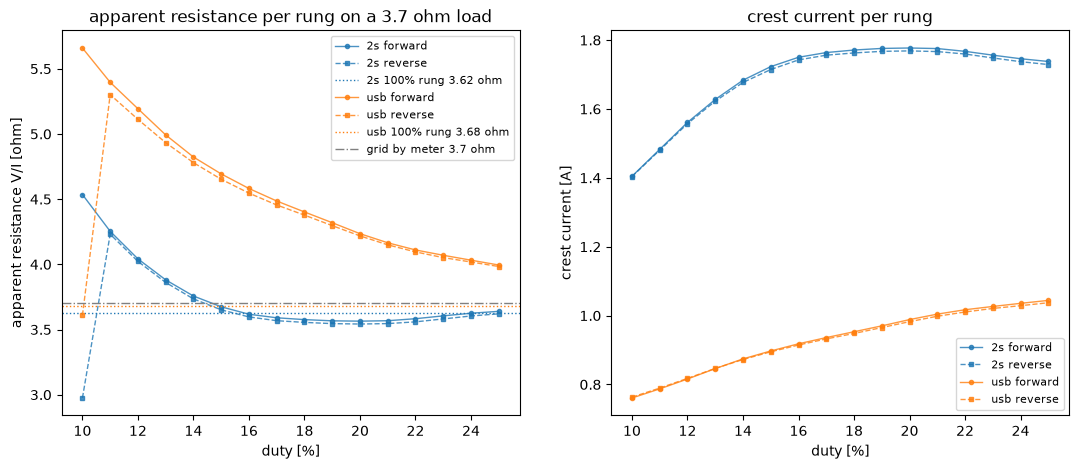

R_app_ohm                         current_A                          \
supply          2s             usb                2s             usb           
dir        forward reverse forward reverse   forward reverse forward reverse   
duty_pct                                                                       
10          4.5356  2.9750  5.6595  3.6083    1.4045  1.4036  0.7607  0.7633   
12          4.0420  4.0226  5.1936  5.1121    1.5610  1.5574  0.8159  0.8177   
15          3.6746  3.6513  4.6936  4.6525    1.7229  1.7145  0.8973  0.8949   
20          3.5644  3.5424  4.2353  4.2184    1.7770  1.7686  0.9884  0.9824   
25          3.6397  3.6205  3.9950  3.9834    1.7379  1.7290  1.0441  1.0373   
100         3.6375  3.6099  3.6894  3.6682    1.7265  1.7196  1.1280  1.1244   

         terminal_diff_V                          
supply                2s             usb          
dir              forward reverse forward reverse  
duty_pct                                          
10                6.3702  4.1757  4.3053  2.7540  
12                6.3096  6.2646  4.2372  4.1801  
15                6.3311  6.2601  4.2116  4.1635  
20                6.3340  6.2651  4.1860  4.1441  
25                6.3254  6.2598  4.1713  4.1321  
100               6.2800  6.2075  4.1618  4.1245

In [20]:
# Same idea as ladder_r.py from the bringup repo. On a resistor the crest
# current is V_on / R at every duty, so each rung hands over an apparent
# resistance with no duty term and no intercept in it. Flat across duty means
# the sampling is honest at that duty. Rising at low duty means the crest
# sample is landing while the chain is still moving.
SKIP_SAMPLES = 40    # 2 ms after the rung opens, for the rail and the taps to settle

def ladder_rungs(ds, supply):
    out = []
    for cap in ds.captures("ladder"):
        for rec in ds.recordings("ladder", cap):
            df = rec.frame()                      # checks the sense block for us
            base = df[df["seg"] == 0]
            base = base.iloc[len(base) // 2:]     # second half of the baseline
            bias = base["current_raw"].median()
            for seg, g in df[df["seg"] > 0].groupby("seg"):
                g = g.iloc[SKIP_SAMPLES:]
                if len(g) < 20:
                    continue
                duty = g["cmd_duty_q15"].iloc[0] * 100.0 / Q15
                i = abs(gboard.amps(g["current_raw"].mean(), bias)) * K_VDD
                v = abs(gboard.diff_v(g["vmotor_a"].mean(), g["vmotor_b"].mean())) * K_VDD
                out.append({"supply": supply, "capture": cap, "recording": rec.name,
                            "seg": seg, "duty_pct": abs(round(duty)),
                            "dir": "forward" if duty > 0 else "reverse",
                            "current_A": i, "terminal_diff_V": v, "R_app_ohm": v / i,
                            "rail_V": gboard.vsys_v(g["vbus_raw"].mean()) * K_VDD})
    return out

RUNGS = pd.DataFrame(sum((ladder_rungs(GDS[k], k) for k in ("2s", "usb")), []))
LAD = (RUNGS.groupby(["supply", "dir", "duty_pct"])
       .agg(rungs=("R_app_ohm", "size"), current_A=("current_A", "mean"),
            terminal_diff_V=("terminal_diff_V", "mean"),
            R_app_ohm=("R_app_ohm", "mean"), R_sd=("R_app_ohm", "std"),
            rail_V=("rail_V", "mean"))
       .reset_index())

print(f"{RUNGS['capture'].nunique()} captures per supply pooled, "
      f"{len(RUNGS)} rungs total")
for supply in ("2s", "usb"):
    n = RUNGS[RUNGS["supply"] == supply]["capture"].nunique()
    print(f"  {supply}: {n} captures, "
          f"{len(RUNGS[RUNGS['supply'] == supply])} rungs")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for supply in ("2s", "usb"):
    for direction, style in (("forward", "-o"), ("reverse", "--s")):
        s = LAD[(LAD["supply"] == supply) & (LAD["dir"] == direction)
                & (LAD["duty_pct"] < 100)].sort_values("duty_pct")
        axes[0].plot(s["duty_pct"], s["R_app_ohm"], style, ms=3, lw=1,
                     color=COLORS[supply], alpha=0.8,
                     label=f"{supply} {direction}")
        axes[1].plot(s["duty_pct"], s["current_A"], style, ms=3, lw=1,
                     color=COLORS[supply], alpha=0.8,
                     label=f"{supply} {direction}")
    # The 100% rung is the switching-free reference. All three reference lines
    # land within 0.07 ohm of each other, so they go in the legend rather than
    # as annotations that would sit on top of one another.
    top = LAD[(LAD["supply"] == supply) & (LAD["duty_pct"] == 100)]
    axes[0].axhline(top["R_app_ohm"].mean(), color=COLORS[supply], lw=1.0, ls=":",
                    label=f"{supply} 100% rung {top['R_app_ohm'].mean():.2f} ohm")
axes[0].axhline(R_GRID, color="grey", lw=1.0, ls="-.",
                label=f"grid by meter {R_GRID:.1f} ohm")
axes[0].set_xlabel("duty [%]")
axes[0].set_ylabel("apparent resistance V/I [ohm]")
axes[0].set_title("apparent resistance per rung on a 3.7 ohm load")
axes[0].legend(fontsize=8)
axes[1].set_xlabel("duty [%]")
axes[1].set_ylabel("crest current [A]")
axes[1].set_title("crest current per rung")
axes[1].legend(fontsize=8)
plt.show()

SHOW = [10, 12, 15, 20, 25, 100]
tab = (LAD[LAD["duty_pct"].isin(SHOW)]
       .pivot_table(index="duty_pct", columns=["supply", "dir"],
                    values=["R_app_ohm", "current_A", "terminal_diff_V"]))
tab.round(4)

In [21]:
# Where does the crest sample become honest? On a resistor the 100% rung is the
# switching-free control, so take its apparent resistance as truth and walk the
# ladder DOWN from its top rung, stopping at the first duty that leaves a
# tolerance band around it. Walking down matters: the reverse 10% rung sits
# BELOW the reference rather than above it (its terminal reading is the one
# that is early, not its current), so a one-sided test would wave it through.
TOL_PCT = 3.0

FLOORS = {}
for supply in ("2s", "usb"):
    for direction in ("forward", "reverse"):
        s = (LAD[(LAD["supply"] == supply) & (LAD["dir"] == direction)]
             .set_index("duty_pct").sort_index())
        ref = s.loc[100, "R_app_ohm"]
        rungs = s[s.index < 100]
        floor = None
        for duty in sorted(rungs.index, reverse=True):
            if abs(rungs.loc[duty, "R_app_ohm"] / ref - 1) * 100 > TOL_PCT:
                break
            floor = duty
        FLOORS[(supply, direction)] = floor
        off25 = (rungs.loc[25, "R_app_ohm"] / ref - 1) * 100
        off10 = (rungs.loc[10, "R_app_ohm"] / ref - 1) * 100
        print(f"{supply:>3} {direction:<8} 100% rung {ref:.4f} ohm | "
              f"25% rung {off25:+6.1f}% | 10% rung {off10:+6.1f}% | "
              + (f"honest to {TOL_PCT:.0f}% from {floor:.0f}% duty" if floor
                 else f"no rung in the ladder is within {TOL_PCT:.0f}%"))
print()

# USB never reaches the band inside the ladder, so its floor has to be
# extrapolated. A straight line over the top five rungs says where it would
# cross, and that crossing is OUTSIDE the measured range, so it is a guess with
# a slope behind it and not a measurement.
s = (LAD[(LAD["supply"] == "usb") & (LAD["dir"] == "forward")]
     .set_index("duty_pct").sort_index())
ref = s.loc[100, "R_app_ohm"]
seg = s.loc[20:25]
k = np.polyfit(seg.index.astype(float), seg["R_app_ohm"], 1)
USB_FLOOR_EXTRAP = (ref * (1 + TOL_PCT / 100) - k[1]) / k[0]
print(f"usb: a line over the 20-25% rungs falls {k[0]:.4f} ohm per duty point "
      f"and crosses the {TOL_PCT:.0f}% band at {USB_FLOOR_EXTRAP:.0f}% duty "
      f"(extrapolated, the ladder stops at 25%)")
print()

# And the reverse 10% rung, which is a different problem entirely: not the
# current channel being early, but the voltage channel.
for supply in ("2s", "usb"):
    s = LAD[LAD["supply"] == supply].set_index(["dir", "duty_pct"]).sort_index()
    for direction in ("forward", "reverse"):
        v10 = s.loc[(direction, 10), "terminal_diff_V"]
        plat = s.loc[direction].loc[20:25, "terminal_diff_V"].mean()
        print(f"{supply:>3} {direction:<8} 10% rung terminal difference "
              f"{v10:.4f} V, 20-25% plateau {plat:.4f} V, ratio {v10 / plat:.4f}")

 2s forward  100% rung 3.6375 ohm | 25% rung   +0.1% | 10% rung  +24.7% | honest to 3% from 15% duty
 2s reverse  100% rung 3.6099 ohm | 25% rung   +0.3% | 10% rung  -17.6% | honest to 3% from 15% duty
usb forward  100% rung 3.6894 ohm | 25% rung   +8.3% | 10% rung  +53.4% | no rung in the ladder is within 3%
usb reverse  100% rung 3.6682 ohm | 25% rung   +8.6% | 10% rung   -1.6% | no rung in the ladder is within 3%

usb: a line over the 20-25% rungs falls -0.0469 ohm per duty point and crosses the 3% band at 29% duty (extrapolated, the ladder stops at 25%)

 2s forward  10% rung terminal difference 6.3702 V, 20-25% plateau 6.3311 V, ratio 1.0062
 2s reverse  10% rung terminal difference 4.1757 V, 20-25% plateau 6.2622 V, ratio 0.6668
usb forward  10% rung terminal difference 4.3053 V, 20-25% plateau 4.1790 V, ratio 1.0302
usb reverse  10% rung terminal difference 2.7540 V, 20-25% plateau 4.1377 V, ratio 0.6656


**What you are looking at:** the apparent resistance of a 3.7 ohm resistor as
the board sees it, rung by rung, and the crest current that produced it. A flat
line at the meter's 3.7 ohm would mean the chain is honest at every duty in the
ladder.

Findings:

- **On 2S the ladder is honest from 15% duty**, in both directions, against a
  3% tolerance on the 100% rung. That 100% rung is the switching-free control
  and it reads 3.64 ohm forward against the meter's 3.7. Below 15% it walks
  away fast. The 12% rung reads 11% high and the 10% rung reads 25% high.
  Nothing about the load changed across those rungs, so the whole rise is the
  sampling.
- **On USB the ladder never gets there.** The 100% rung reads 3.69 ohm, the 25%
  rung is 8.3% above it and the 10% rung is 53% above it. Not one rung in the
  10 to 25% ladder is honest to 3%. A line through the top five rungs falls
  0.047 ohm per duty point and crosses the 3% band near 29% duty, which is an
  extrapolation past the end of the data, and section 10.6 argues for a number
  nearer 35%. So the USB floor is somewhere around 30%, and it was not
  measured.
- **The crest current panel says the same thing from the other side.** On 2S
  the current is at its plateau by 15% and the apparent rise below that is the
  terminal voltage staying put while the current reads low. On USB the current
  is still climbing at the top of the ladder.
- **The reverse 10% rung is a different fault, and it is a voltage one.** Its
  terminal difference reads 0.667 of the plateau on 2S and 0.666 on USB, while
  the forward 10% rung reads 1.006 and 1.030. A 10% duty is 120 timer ticks and
  the board entry's voltage floor is 160, so the tap has not settled when the
  scan arrives, which is what section 5.4 measured on the servo. What section
  5.4 could not say, and this can, is that the miss is
  **direction-asymmetric**. Forward reads the full plateau at the same 120
  ticks and reverse reads two thirds of it. Same parts, same scan, so the
  asymmetry belongs to which tap is being driven high, and it lines up with the
  island geometry from section 10.4.
- That rung is also why the floor search above walks DOWN the ladder instead of
  testing each rung on its own. The reverse 10% rung comes out 17.6% LOW on 2S
  and 1.6% low on USB, because its voltage is early rather than its current, so
  a one-sided "is it too high" test waves it straight through.

### 10.6 The ON-window waveform

burst sample period 1.0833 us, PWM period 50.0 us, 46.15 samples per period


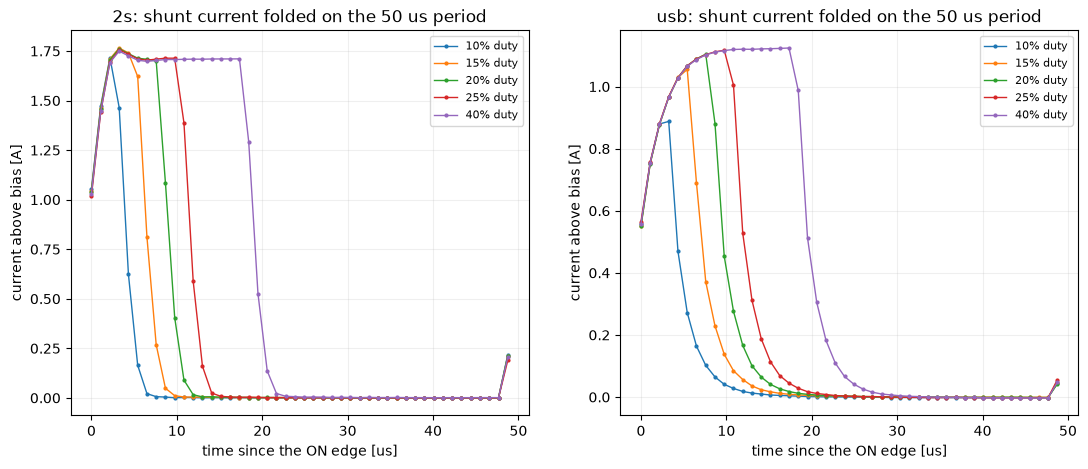

mean current per slot, first 12 slots after the ON edge, in A above bias


slot                0      1      2      3      4      5      6      7   \
supply duty_pct                                                           
2s     10        1.053  1.472  1.717  1.465  0.623  0.165  0.021  0.006   
       15        1.043  1.462  1.711  1.765  1.740  1.621  0.812  0.268   
       20        1.039  1.458  1.706  1.761  1.737  1.714  1.708  1.700   
       25        1.018  1.441  1.695  1.756  1.734  1.710  1.704  1.709   
       40        1.031  1.445  1.692  1.749  1.726  1.704  1.698  1.702   
usb    10        0.557  0.755  0.880  0.888  0.469  0.272  0.164  0.102   
       15        0.552  0.753  0.878  0.967  1.030  1.055  0.689  0.372   
       20        0.550  0.752  0.877  0.966  1.028  1.067  1.089  1.105   
       25        0.565  0.758  0.881  0.968  1.029  1.067  1.089  1.103   
       40        0.558  0.755  0.879  0.966  1.027  1.065  1.087  1.102   

slot                8      9      10     11  
supply duty_pct                              
2s     10        0.004  0.001  0.002  0.002  
       15        0.049  0.011  0.004  0.004  
       20        1.085  0.405  0.090  0.016  
       25        1.714  1.714  1.388  0.588  
       40        1.707  1.707  1.708  1.709  
usb    10        0.065  0.041  0.028  0.018  
       15        0.229  0.138  0.085  0.056  
       20        0.881  0.453  0.276  0.166  
       25        1.112  1.117  1.005  0.528  
       40        1.111  1.116  1.120  1.120

In [22]:
# The bursts free-run the ADC on the shunt alone, so they show what happens
# INSIDE one PWM period, which the 20 kHz crest sample can only ever see one
# slice of. Two constants the board entry does not carry:
#
#   burst sample period: the ADC runs at 24 MHz and one conversion is a
#   13.5-cycle sample aperture plus 12.5 cycles of conversion, so 26 ADC clocks
#   per sample, 26 / 24 MHz = 1.0833 us.
#   PWM period: 20 kHz centre aligned, which is the board's tick rate, so
#   50 us, which works out at about 46 burst samples.
BURST_TS_US = 26 / 24.0
PWM_PERIOD_US = 1e6 / gboard.tick_hz
BURST_SLOTS = PWM_PERIOD_US / BURST_TS_US
BURST_DUTIES = [10, 15, 20, 25, 40]

print(f"burst sample period {BURST_TS_US:.4f} us, PWM period {PWM_PERIOD_US:.1f} us, "
      f"{BURST_SLOTS:.2f} samples per period")

def fold_burst(path):
    """Average one burst over its PWM periods, aligned on the ON edge."""
    raw = pd.read_csv(path)
    meta = raw.iloc[0]
    frame_len = int(meta["frame_len"])
    counts = raw["raw"].to_numpy(float)
    if frame_len != 1:                       # interleaved scans: slot 0 is the shunt
        counts = counts[::frame_len]
    # The burst carries its own bias, taken at rest just before it ran.
    amps = gboard.amps(counts, float(meta["bias"])) * K_VDD
    duty = int(meta["step_q15"]) * 100.0 / Q15
    # The ON edge is the biggest positive jump in each period. Aligning on the
    # median phase rather than on one edge keeps a single noisy period from
    # shifting the whole fold.
    step = np.diff(amps)
    edges = np.where(step > 0.25 * (amps.max() - amps.min()))[0]
    phase = np.median(edges % BURST_SLOTS)
    slots = int(round(BURST_SLOTS))
    nper = int(len(amps) // BURST_SLOTS) - 1
    prof = np.full((nper, slots), np.nan)
    for k in range(nper):
        s = int(round(phase + k * BURST_SLOTS)) + 1
        chunk = amps[s:s + slots]
        prof[k, :len(chunk)] = chunk
    return np.nanmean(prof, axis=0), duty, nper, float(meta["vbus_raw"])

FOLDS = {}
rows = []
for supply in ("2s", "usb"):
    d = GDS[supply].path / "burst"
    for duty in BURST_DUTIES:
        # chans 0 = shunt only, frame_len 1. Two repeats per duty, averaged.
        reps = [fold_burst(d / f"c0-d{duty}-{rep}.csv") for rep in (0, 1)]
        prof = np.nanmean([r[0] for r in reps], axis=0)
        FOLDS[(supply, duty)] = prof
        on_slots = max(2, int(round(duty / 100 * BURST_SLOTS)))
        rows.append({"supply": supply, "duty_pct": duty, "repeats": len(reps),
                     "periods": reps[0][2], "ON_slots": on_slots,
                     "ON_us": on_slots * BURST_TS_US,
                     "peak_A": np.nanmax(prof[:on_slots]),
                     "rail_V": gboard.vsys_v(np.mean([r[3] for r in reps])) * K_VDD})
BURSTS = pd.DataFrame(rows).set_index(["supply", "duty_pct"])

fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=False)
for ax, supply in zip(axes, ("2s", "usb")):
    for duty in BURST_DUTIES:
        prof = FOLDS[(supply, duty)]
        t = np.arange(len(prof)) * BURST_TS_US
        ax.plot(t, prof, "-", lw=1, ms=2, marker="o", label=f"{duty}% duty")
    ax.set_xlabel("time since the ON edge [us]")
    ax.set_title(f"{supply}: shunt current folded on the 50 us period")
    ax.grid(alpha=0.2)
    ax.legend(fontsize=8)
axes[0].set_ylabel("current above bias [A]")
axes[1].set_ylabel("current above bias [A]")
plt.show()

print("mean current per slot, first 12 slots after the ON edge, in A above bias")
slot_tab = pd.DataFrame(
    {(supply, duty): np.round(FOLDS[(supply, duty)][:12], 3)
     for supply in ("2s", "usb") for duty in BURST_DUTIES}).T
slot_tab.index.names = ["supply", "duty_pct"]
slot_tab.columns.name = "slot"
slot_tab

In [23]:
# How many slots does the current need before it STAYS within 1% of the
# plateau? The 40% burst has the longest ON window, so it is the one that shows
# the whole approach. The plateau is taken a couple of slots short of the fall
# edge, because at 40% duty the ON window is 18.5 slots and the last slot in it
# is already falling.
SETTLE_TOL = 0.01

def settle_slot(prof, duty):
    on = int(round(duty / 100 * BURST_SLOTS))
    plateau = np.nanmean(prof[on - 6:on - 2])
    inside = np.abs(prof[:on - 2] - plateau) <= SETTLE_TOL * plateau
    first = len(inside)
    while first > 0 and inside[first - 1]:      # walk back while it stays in
        first -= 1
    return first, plateau, on

for supply in ("2s", "usb"):
    first, plateau, on = settle_slot(FOLDS[(supply, 40)], 40)
    # The crest sample is triggered at the counter crest, which is the middle of
    # the ON window, so the duty that puts it past that slot is:
    duty_needed = first * 2 / BURST_SLOTS * 100
    print(f"{supply:>3}: plateau {plateau:.3f} A, stays within "
          f"{SETTLE_TOL * 100:.0f}% from slot {first} "
          f"({first * BURST_TS_US:.1f} us after the ON edge), so a centred crest "
          f"sample clears it from {duty_needed:.0f}% duty")
print()

# The 2S approach is not monotonic, which is worth seeing before calling it a
# settling time.
p = FOLDS[("2s", 40)]
print("2s 40% first six slots: " + " ".join(f"{x:.3f}" for x in p[:6])
      + f"  (slot 3 overshoots the plateau by "
        f"{(p[3] / np.nanmean(p[12:16]) - 1) * 100:.1f}%)")

# The OFF window, where the two supplies differ in kind and not just in degree.
for supply in ("2s", "usb"):
    prof = FOLDS[(supply, 25)]
    on = int(round(25 / 100 * BURST_SLOTS))
    print(f"{supply:>3}: OFF window, five slots after the fall edge: "
          + " ".join(f"{x:.2f}" for x in prof[on + 1:on + 6]) + " A")
print()

# And the plateau against the 100% DC lap, which is the same current with no
# switching in it at all.
lap_i = LAPS.loc["1", "amps_A"]
burst_i = np.nanmean(FOLDS[("2s", 40)][12:16])
print(f"2s burst plateau {burst_i:.3f} A against the 100% DC lap {lap_i:.3f} A "
      f"({(burst_i / lap_i - 1) * 100:+.1f}%)")

 2s: plateau 1.710 A, stays within 1% from slot 4 (4.3 us after the ON edge), so a centred crest sample clears it from 17% duty
usb: plateau 1.122 A, stays within 1% from slot 8 (8.7 us after the ON edge), so a centred crest sample clears it from 35% duty

2s 40% first six slots: 1.031 1.445 1.692 1.749 1.726 1.704  (slot 3 overshoots the plateau by 2.3%)
 2s: OFF window, five slots after the fall edge: 0.02 0.01 0.00 0.00 0.00 A
usb: OFF window, five slots after the fall edge: 0.19 0.11 0.07 0.04 0.03 A

2s burst plateau 1.710 A against the 100% DC lap 1.699 A (+0.6%)


**What you are looking at:** the shunt current inside one PWM period,
averaged over about 20 periods of a steady burst and over two repeats, with
time measured from the ON edge. The crest sample the control loop actually uses
lands in the middle of the ON window, so these curves say what that one sample
can and cannot see.

Findings:

- **On 2S the current is basically there in three slots and settled in four.**
  1.031 A, 1.445 A, 1.692 A, and then it overshoots to 1.749 A before coming
  back to the 1.710 A plateau. Counting the overshoot, it stays inside 1% of
  the plateau from slot 4, which is 4.3 us after the edge. The session log
  called this settled by slot 3, which is the eyeball version of the same
  thing. The plateau matches the 100% DC lap to 0.6%, which is the cross-check
  that this fold is reading the same current the meter graded in section 10.3.
- **On USB the same edge takes eight slots**, 8.7 us, climbing 0.558, 0.755,
  0.879, 0.966, 1.027, 1.065, 1.087, 1.102 before it holds. And the OFF window
  does not fall to zero the way 2S does. In the five slots after the fall edge
  2S is already at 0.02 A and USB is still at 0.19, 0.11, 0.07, 0.04, 0.03 A.
  That tail is the giveaway. The current is not being limited by the load, it is
  charge coming back out of the board's own capacitors through the shunt.
- **So there are two separate floors, not one.** The first is the amplifier's
  edge. It is about 3 us on the 1k/15k and 33 pF network around the OPA and it
  shows on both supplies, because it belongs to the amplifier and not to the
  rail. The rev-2A network of 6k4 and 430 with 22 pF should roughly halve it.
  The second is island capacitor charge sharing on a soft rail, and it is USB
  only. When the rail cannot hold up, the driver decoupling and bulk capacitors
  near the bridge dump into the load through the shunt at every ON edge, so the
  shunt reads capacitor current mixed in with load current. The fix is a layout
  one, which is to return every driver and bulk capacitor to GND on the far side
  of the shunt so their charge never crosses it.
- **The honest-crest floor on this board is 15% duty on 2S.** Section 10.5
  measures that directly and the fold agrees, because a crest sample centred in
  the ON window clears slot 4 from 17% duty. On USB the two routes disagree.
  The ladder extrapolates to 29% and the fold's slot count says 35%. Neither is
  a measurement, because the USB ladder stops at 25%, so the honest answer is
  around 30% with a 10 point spread on it, and the experiment that settles it is
  a USB ladder that runs to 50%.

## 11. Report card

In [24]:
# One row per channel. The rest noise is recomputed here from the GRID
# captures' segment 0 rather than reused from section 5, for two reasons: it is
# the same board and the same firmware build, and a static load has no shaft,
# so the baseline has no settling head in it at all. That last part is worth
# saying out loud, because on the servo the first 200 ms of a baseline is the
# shaft ringing down and taking the standard deviation over the whole second
# inflates position 6.6x. Here the two agree to under a percent, which is what
# a baseline with no mechanism in it should look like.
NOISE_CH = {"pos": "position", "current_raw": "current",
            "vmotor_a": "terminal A", "vmotor_b": "terminal B",
            "vbus_raw": "supply sense"}

rows = []
for cap in GDS["2s"].captures("ladder"):
    b = GDS["2s"].read("ladder", cap, "ladder")
    b = b[b["seg"] == 0]
    rows.append({**{c: b[c].std() for c in NOISE_CH},
                 **{c + "_mean": b[c].mean() for c in NOISE_CH},
                 **{c + "_head_dropped": b.iloc[4000:][c].std() for c in NOISE_CH}})
NOISE = pd.DataFrame(rows).mean()
print("rest noise sd on the 2S grid baseline, counts, "
      f"{len(rows)} captures pooled")
for c, name in NOISE_CH.items():
    print(f"  {name:<13} mean {NOISE[c + '_mean']:8.1f} counts | sd whole baseline "
          f"{NOISE[c]:.3f} | sd first 4000 samples dropped "
          f"{NOISE[c + '_head_dropped']:.3f}")
print()

# The bus-coupling check from the traps list, re-run on this scan geometry.
b = GDS["2s"].read("ladder", "capture-1", "ladder")
b = b[b["seg"] == 0]
by_slot = b.groupby(b["tick"] % 16)["current_raw"].mean()
print(f"rest current binned by position in the 16-sample frame: spread "
      f"{by_slot.max() - by_slot.min():.3f} counts against a sample sd of "
      f"{b['current_raw'].std():.3f} counts")
print()

# Per count, in the physical unit of each channel. All VDD corrected, because
# these are absolute.
per_count = {
    "position": (gboard.v_adc_per_count * K_VDD * 1e3, "mV at the wiper"),
    "current": (gboard.a_per_count * K_VDD * 1e3, "mA through the shunt"),
    "terminal A": (gboard.v_adc_per_count * gboard.div_ratio * K_VDD * 1e3, "mV at the terminal"),
    "terminal B": (gboard.v_adc_per_count * gboard.div_ratio * K_VDD * 1e3, "mV at the terminal"),
    "supply sense": (gboard.v_adc_per_count * gboard.vbus_ratio * K_VDD * 1e3, "mV at the rail"),
}

term_err = f"inside the meter's band on 3 of 5 laps, worst {worst_band:.2f}% outside it"
card = []
for col, name in NOISE_CH.items():
    step, unit = per_count[name]
    sd = NOISE[col]
    card.append({
        "channel": name,
        "resolution": f"1 count = {step:.3f} {unit}",
        "rest noise sd": f"{sd:.2f} counts ({sd * step:.2f} {unit.split(' ')[0]})",
        "absolute error vs instrument": {
            "position": "not checked, there is no angle reference on this rig",
            "current": f"{CUR['error_pct'].mean():+.1f}% at 1.7 A, bracket "
                       f"{bracket:.1f}% from the grid's last digit",
            "terminal A": term_err,
            "terminal B": term_err,
            "supply sense": "not checked against a meter; agrees with terminal A "
                            f"plus the {fwd['hs_drop_V']:.2f} V high-side drop",
        }[name],
        "known systematics": {
            "position": "pot local gain swings 5.8x with position (nb06 sec 6); "
                        "scale disputed 3.3% (sec 2)",
            "current": "amplifier edge about 3 us; island-cap charge sharing on a "
                       "soft rail; direction-dependent by 1.3% against the terminals",
            "terminal A": "120-tick window under the 160-tick floor below 15% duty; "
                          "driven-low reads (r-1)/r x VB, not zero",
            "terminal B": "same window floor, and reverse reads 0.67 of the plateau "
                          "at 10% duty; 4-count rest split against A (sec 9.3)",
            "supply sense": "metadata vbus_counts is pre-scaled into tap units "
                            "(sec 9.1); divider legs never ohmmetered",
        }[name],
        "rev-2A mitigation": {
            "position": "none on the board; an IR encoder is the long-term answer",
            "current": "6k4/430 with 22 pF halves the edge; every driver and bulk "
                       "cap returns to GND outside the shunt loop; symmetric Kelvin "
                       "entry at the shunt pads",
            "terminal A": "1% divider legs; 6k8/3k3 with 150 pF taps",
            "terminal B": "same, plus a scan-slot swap to settle sec 9.3",
            "supply sense": "1% legs and an ohmmeter check before assembly",
        }[name],
    })
CARD = pd.DataFrame(card).set_index("channel")
pd.set_option("display.max_colwidth", 90)
CARD

rest noise sd on the 2S grid baseline, counts, 5 captures pooled
  position      mean   1838.9 counts | sd whole baseline 1.436 | sd first 4000 samples dropped 1.436
  current       mean    106.7 counts | sd whole baseline 1.697 | sd first 4000 samples dropped 1.698
  terminal A    mean    779.2 counts | sd whole baseline 0.820 | sd first 4000 samples dropped 0.820
  terminal B    mean    783.1 counts | sd whole baseline 1.061 | sd first 4000 samples dropped 1.062
  supply sense  mean   3557.1 counts | sd whole baseline 2.166 | sd first 4000 samples dropped 2.165

rest current binned by position in the 16-sample frame: spread 0.586 counts against a sample sd of 1.716 counts



,resolution,rest noise sd,absolute error vs instrument,known systematics,rev-2A mitigation
channel,,,,,
position,1 count = 0.801 mV at the wiper,1.44 counts (1.15 mV),"not checked, there is no angle reference on this rig",pot local gain swings 5.8x with position (nb06 sec 6); scale disputed 3.3% (sec 2),none on the board; an IR encoder is the long-term answer
current,1 count = 0.890 mA through the shunt,1.70 counts (1.51 mA),"+1.2% at 1.7 A, bracket 2.7% from the grid's last digit",amplifier edge about 3 us; island-cap charge sharing on a soft rail; direction-depende...,6k4/430 with 22 pF halves the edge; every driver and bulk cap returns to GND outside t...
terminal A,1 count = 2.451 mV at the terminal,0.82 counts (2.01 mV),"inside the meter's band on 3 of 5 laps, worst 0.44% outside it",120-tick window under the 160-tick floor below 15% duty; driven-low reads (r-1)/r x VB...,1% divider legs; 6k8/3k3 with 150 pF taps
terminal B,1 count = 2.451 mV at the terminal,1.06 counts (2.60 mV),"inside the meter's band on 3 of 5 laps, worst 0.44% outside it","same window floor, and reverse reads 0.67 of the plateau at 10% duty; 4-count rest spl...","same, plus a scan-slot swap to settle sec 9.3"
supply sense,1 count = 2.002 mV at the rail,2.17 counts (4.34 mV),not checked against a meter; agrees with terminal A plus the 0.11 V high-side drop,metadata vbus_counts is pre-scaled into tap units (sec 9.1); divider legs never ohmmet...,1% legs and an ohmmeter check before assembly


**What you are looking at:** every raw channel with what one count is worth,
how quiet it is at rest, and how far off it was when an instrument looked at
the same node.

Two things fall out of the noise numbers on the way past. The rest current
binned by its position inside the 16-sample telemetry frame is flat to 0.59
counts against a sample standard deviation of 1.72, so the bus coupling this
board is known for does not show at rest on this scan geometry. And dropping
the first 4000 samples of the baseline changes nothing here, where on the servo
it changes position by 6.6x. That is the cleanest confirmation yet that the
inflation on the servo is the shaft ringing down and not a noise floor.

**What the next board is measured against.** The terminal chain is now a
reference, not an assumption. It reads within half a percent of a meter at
1.7 A in both directions, so a rev-2A board that disagrees with its own
terminals has a fault, and the terminals are the thing to trust while chasing
it. The current chain is good to about 1% with a 3% bracket, which is enough to
say there is no scale error and not enough to calibrate against, so the target
for the next session is a series ammeter and a 1% number. The crest current is
honest from 15% duty on 2S and the rev-2A target is 8%, falling to 3 or 4% once
the scan samples late in the ON window instead of at the crest. Those are the
numbers the next board has to beat.

**What this session could not check.**

- **A series ammeter.** The meter's 10 A jack is dead, so there is no
  independent current reading anywhere in this session and the whole current
  result rides on the grid's 3.7 ohm. A fuse fixes it.
- **The VSNS divider legs by ohmmeter.** Section 9.1 is refuted by agreement
  between two routes on the same recording, which is weaker than measuring the
  two resistors with the board unpowered. That measurement is still owed.
- **Absolute angle.** A resistor grid has no shaft, so the position channel got
  nothing out of this session at all. Its noise floor is here and its scale is
  not. The pot scale stays disputed, and the servo registry still carries both
  numbers with their brackets.
- **The shunt separately from the gain.** Millivolts across the RS1 pads would
  have split the 60 mOhm from the gain of 15, and that reading was not taken.
  Everything here grades the product of the two.
- **Temperature.** The grid heats at 10.7 W and its tempco is unmeasured. The
  cold-against-warm pair in section 10.4 bounds it at 0.3% over the laps that
  were run, which is not the same as knowing it.

## 12. Handoff

The chain now has an instrument behind it, so the next notebooks can quote
absolute amps without the hedge that used to go with them. Three things go out
of here.

Notebook 01 gates samples on bridge state, and section 10.6 says what the
gating is fighting. A crest sample below 15% duty on 2S is not a current
reading, it is an amplifier still slewing, so the bridge-state gate needs a
duty floor next to it.

Notebook 02 owns the electrical fits, and the 0.61% VDD correction moves every
absolute number it has produced. The winding resistance and the loop time
constant both need a pass with $K_{VDD}$ applied.

The rev-2A board carries three changes out of this session. Every driver and
bulk capacitor returns to GND on the far side of the shunt, the shunt pads get
a symmetric Kelvin entry from both low FETs, and the OPA network goes to 6k4
and 430 with 22 pF. When the first rev-2A board comes up, run this same
session on it. The grid is still soldered.